# Economic Consequences of Interstate War:  
## Comparing Winners and Losers Before, During and After Conflict

## Introduction

War can disrupt production, trade and public finances, but the economic path is not the same for every country. This project compares real GDP per capita before, during and after interstate wars, focusing on eventual winners and losers.

GDP per capita is indexed to each participant's own five-year pre-war average (=100), allowing countries from different eras and income levels to be compared on the same relative scale. The final sample contains 97 country-war observations from 25 wars and 53 countries. Overall, winners tend to be stronger immediately after war, while losers more often fall below baseline during wartime, but the gap is not consistent across the full ten-year recovery window.

## Research Topic and Background

The project combines the **Correlates of War (COW)** interstate-war records with the **Maddison Project Database 2020 (MPD2020)**. COW provides participant-specific entry/exit dates and outcome codes (Sarkees and Wayman, 2010), while MPD2020 provides long-run real GDP per capita (Bolt and van Zanden, 2020).

To compare very different economies, each country-war observation is converted to event time and normalised to a pre-war GDP index of 100. Here, **winner** and **loser** are COW outcome categories, not moral judgements.

### Research Questions

1. **How does real GDP per capita change from the pre-war period through wartime and into the ten-year post-war period?**
2. **Do eventual winners and losers follow different GDP-per-capita trajectories?**
3. **How does wartime economic disruption differ between winners and losers?**
4. **How quickly do winning and losing countries recover to their pre-war economic level?**
5. **How do multiple wartime and post-war economic indicators vary jointly across winners and losers?**

## Data Sources

### Maddison Project Database 2020

MPD2020 provides long-run GDP and population estimates for 169 countries up to 2018 (Bolt and van Zanden, 2020). This project uses `country`, `year` and real GDP per capita (`gdppc`). Historical observations are reconstructed estimates, so older values carry more uncertainty than modern national accounts.

### Correlates of War Inter-State War Data v4.0

COW Inter-State War Data v4.0 is participant-level conflict data containing war names, states, participant-specific dates and outcomes. The raw file contains 337 participant records across 95 interstate wars. Using participant-level dates avoids treating a country as being at war before it actually entered the conflict (Sarkees and Wayman, 2010).

### Data Trustworthiness, Validity and Ethical Considerations

Both sources are established academic datasets but require judgement. Historical state boundaries do not always match modern economic series, so ambiguous mappings were excluded rather than forced. GDP also measures economic output, not casualties, displacement or welfare; a return to baseline should not be interpreted as a positive judgement about a war. The analysis contains aggregate country-level data and no personal information.

## Data Overview and Pre-Processing

### Initial Inspection and Conflict Selection

In [1]:
%pip install -q openpyxl pyshp

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path


DATA_DIR = Path("datasets-for-final")

cow_path = DATA_DIR / "Inter-StateWarData_v4.0.csv"
mpd_path = DATA_DIR / "mpd2020.xlsx"

cow = pd.read_csv(cow_path, encoding="latin1")
mpd = pd.read_excel(mpd_path, sheet_name="Full data")

print("COW shape:", cow.shape)
print("Maddison shape:", mpd.shape)

COW shape: (337, 25)
Maddison shape: (21682, 5)


In [3]:
print("COW columns:")
print(cow.columns.tolist())

print("\nMaddison columns:")
print(mpd.columns.tolist())

print("\nNumber of interstate wars:", cow["WarNum"].nunique())
print("COW participant records:", len(cow))
print("Maddison countries:", mpd["country"].nunique())

print(
    "Maddison year range:",
    mpd["year"].min(),
    "to",
    mpd["year"].max()
)

COW columns:
['WarNum', 'WarName', 'WarType', 'ccode', 'StateName', 'Side', 'StartMonth1', 'StartDay1', 'StartYear1', 'EndMonth1', 'EndDay1', 'EndYear1', 'StartMonth2', 'StartDay2', 'StartYear2', 'EndMonth2', 'EndDay2', 'EndYear2', 'TransFrom', 'WhereFought', 'Initiator', 'Outcome', 'TransTo', 'BatDeath', 'Version']

Maddison columns:
['countrycode', 'country', 'year', 'gdppc', 'pop']

Number of interstate wars: 95
COW participant records: 337
Maddison countries: 169
Maddison year range: 1 to 2018


### Outcome Classification

In [4]:
outcome_labels = {
    1: "Winner",
    2: "Loser",
    3: "Compromise/Tied",
    4: "Transformed into another war",
    5: "Ongoing",
    6: "Stalemate",
    7: "Continues below war level",
    8: "Changed sides"
}

print(cow["Outcome"].value_counts().sort_index())

cow["outcome_label"] = cow["Outcome"].map(outcome_labels)

print("\nOutcome distribution:")
print(cow["outcome_label"].value_counts())

Outcome
1    155
2    119
3      4
4     28
6     30
8      1
Name: count, dtype: int64

Outcome distribution:
outcome_label
Winner                          155
Loser                           119
Stalemate                        30
Transformed into another war     28
Compromise/Tied                   4
Changed sides                     1
Name: count, dtype: int64


In [5]:
war_summary = (
    cow.groupby(["WarNum", "WarName"])
       .agg(
           start_year=("StartYear1", "min"),
           end_year=("EndYear1", "max"),
           participants=("StateName", "nunique")
       )
       .reset_index()
)

print("All wars:", len(war_summary))

print(
    "\nWars beginning from 1870:",
    (war_summary["start_year"] >= 1870).sum()
)

war_summary.head(10)

All wars: 95

Wars beginning from 1870: 76


,WarNum,WarName,start_year,end_year,participants
0,1,Franco-Spanish War,1823,1823,2
1,4,First Russo-Turkish,1828,1829,2
2,7,Mexican-American,1846,1847,2
3,10,Austro-Sardinian,1848,1848,4
4,13,First Schleswig-Holstein,1848,1848,2
5,16,Roman Republic,1849,1849,4
6,19,La Plata,1851,1852,2
7,22,Crimean,1853,1856,5
8,25,Anglo-Persian,1856,1857,2
9,28,Italian Unification,1859,1859,3


In [6]:
# Identify wars that began in or after 1870
wars_from_1870 = war_summary.loc[
    war_summary["start_year"] >= 1870,
    "WarNum"
]

# Keep all participant records belonging to those wars
cow_1870 = cow[cow["WarNum"].isin(wars_from_1870)].copy()

print("Participant records before filtering:", len(cow))
print("Participant records from 1870 onward:", len(cow_1870))
print("Wars from 1870 onward:", cow_1870["WarNum"].nunique())

Participant records before filtering: 337
Participant records from 1870 onward: 279
Wars from 1870 onward: 76


In [7]:
outcome_labels = {
    1: "Winner",
    2: "Loser",
    3: "Compromise/Tied",
    4: "Transformed into another war",
    5: "Ongoing",
    6: "Stalemate",
    7: "Continues below war level",
    8: "Changed sides"
}

cow_1870["outcome_label"] = cow_1870["Outcome"].map(outcome_labels)

outcome_counts = (
    cow_1870["outcome_label"]
    .value_counts(dropna=False)
)

print(outcome_counts)

outcome_label
Winner                          126
Loser                            92
Stalemate                        30
Transformed into another war     26
Compromise/Tied                   4
Changed sides                     1
Name: count, dtype: int64


In [8]:
non_decisive = cow_1870[
    ~cow_1870["Outcome"].isin([1, 2])
][
    ["WarNum", "WarName", "StateName", "StartYear1", "EndYear1",
     "Outcome", "outcome_label"]
].sort_values(["WarNum", "StateName"])

non_decisive.head(30)

,WarNum,WarName,StateName,StartYear1,EndYear1,Outcome,outcome_label
129,108,Latvian Liberation,Germany,1918,1919,8,Changed sides
142,116,Franco-Turkish,France,1919,1921,3,Compromise/Tied
141,116,Franco-Turkish,Turkey,1919,1921,3,Compromise/Tied
195,147,First Kashmir,India,1947,1949,6,Stalemate
196,147,First Kashmir,Pakistan,1947,1949,6,Stalemate
216,151,Korean,Australia,1950,1953,6,Stalemate
204,151,Korean,Belgium,1951,1953,6,Stalemate
205,151,Korean,Canada,1950,1953,6,Stalemate
203,151,Korean,China,1950,1953,6,Stalemate
206,151,Korean,Colombia,1951,1953,6,Stalemate


In [9]:
cow_decisive = cow_1870[
    cow_1870["Outcome"].isin([1, 2])
].copy()

cow_decisive["side"] = cow_decisive["Outcome"].map({
    1: "Winner",
    2: "Loser"
})

print("Participant records:", len(cow_decisive))
print("Wars represented:", cow_decisive["WarNum"].nunique())

print("\nWinner/loser observations:")
print(cow_decisive["side"].value_counts())

Participant records: 218
Wars represented: 59

Winner/loser observations:
side
Winner    126
Loser      92
Name: count, dtype: int64


### Country-Name Harmonisation

In [10]:
# Compare country names between the two datasets

cow_countries = set(cow_decisive["StateName"].dropna().unique())
mpd_countries = set(mpd["country"].dropna().unique())

exact_matches = sorted(cow_countries.intersection(mpd_countries))
unmatched_countries = sorted(cow_countries.difference(mpd_countries))

print("Unique COW countries:", len(cow_countries))
print("Exact matches with Maddison:", len(exact_matches))
print("Countries requiring attention:", len(unmatched_countries))

print("\nUnmatched COW country names:")
for country in unmatched_countries:
    print("-", country)

Unique COW countries: 77
Exact matches with Maddison: 59
Countries requiring attention: 18

Unmatched COW country names:
- Austria-Hungary
- Baden
- Bavaria
- Bolivia
- China (PRC)
- Laos
- Russia
- South Korea
- South Vietnam
- Syria
- Taiwan
- Tanzania
- USSR
- United States of America
- Vietnam
- Wuerttemburg
- Yemen Arab Republic
- Yugoslavia


In [11]:
# Search Maddison country names for possible counterparts
search_terms = [
    "Austr",
    "German",
    "Boliv",
    "China",
    "Lao",
    "Russ",
    "Korea",
    "Viet",
    "Syr",
    "Tai",
    "Tanz",
    "USSR",
    "United States",
    "Yemen",
    "Yugo"
]

for term in search_terms:
    matches = [
        country for country in sorted(mpd_countries)
        if term.lower() in country.lower()
    ]

    print(f"{term}: {matches}")

Austr: ['Australia', 'Austria']
German: ['Germany']
Boliv: ['Bolivia (Plurinational State of)', 'Venezuela (Bolivarian Republic of)']
China: ['China', 'China, Hong Kong SAR', 'Taiwan, Province of China']
Lao: ["Lao People's DR"]
Russ: ['Russian Federation']
Korea: ['D.P.R. of Korea', 'Republic of Korea']
Viet: ['Viet Nam']
Syr: ['Syrian Arab Republic']
Tai: ['Taiwan, Province of China']
Tanz: ['U.R. of Tanzania: Mainland']
USSR: ['Former USSR']
United States: ['United States']
Yemen: ['Yemen']
Yugo: ['Former Yugoslavia']


In [12]:
historical_candidates = [
    "Former USSR",
    "Russian Federation",
    "Former Yugoslavia",
    "Serbia",
    "Austria",
    "Germany",
    "Yemen",
    "Viet Nam"
]

for country in historical_candidates:
    subset = mpd[
        (mpd["country"] == country) &
        (mpd["gdppc"].notna())
    ]

    if len(subset) > 0:
        print(
            f"{country}: "
            f"{subset['year'].min()}–{subset['year'].max()}, "
            f"{len(subset)} GDP observations"
        )

Former USSR: 1885–2018, 129 GDP observations
Russian Federation: 1960–2018, 59 GDP observations
Former Yugoslavia: 1870–2018, 97 GDP observations
Serbia: 1952–2018, 67 GDP observations
Austria: 1820–2018, 154 GDP observations
Germany: 1500–2018, 176 GDP observations
Yemen: 1950–2018, 69 GDP observations
Viet Nam: 1820–2018, 72 GDP observations


In [13]:
problem_countries = [
    "Austria-Hungary",
    "Baden",
    "Bavaria",
    "Russia",
    "South Vietnam",
    "Tanzania",
    "USSR",
    "Wuerttemburg",
    "Yemen Arab Republic",
    "Yugoslavia"
]

problem_rows = (
    cow_decisive[
        cow_decisive["StateName"].isin(problem_countries)
    ][
        [
            "WarNum",
            "WarName",
            "StateName",
            "StartYear1",
            "EndYear1",
            "side"
        ]
    ]
    .sort_values(["StateName", "StartYear1"])
)

problem_rows

,WarNum,WarName,StateName,StartYear1,EndYear1,side
122,106,World War I,Austria-Hungary,1914,1918,Loser
59,58,Franco-Prussian,Baden,1870,1870,Winner
61,58,Franco-Prussian,Bavaria,1870,1870,Winner
66,61,Second Russo-Turkish,Russia,1877,1878,Winner
82,82,Boxer Rebellion,Russia,1900,1900,Winner
88,83,Sino-Russian,Russia,1900,1900,Winner
91,85,Russo-Japanese,Russia,1904,1905,Loser
112,106,World War I,Russia,1914,1917,Winner
128,107,Estonian Liberation,Russia,1918,1920,Loser
130,108,Latvian Liberation,Russia,1918,1920,Loser


In [14]:
# Country-name harmonisation between COW and Maddison
# Only clear or defensible correspondences are mapped.
# Ambiguous historical states are deliberately left unmatched.

country_mapping = {
    "Bolivia": "Bolivia (Plurinational State of)",
    "China (PRC)": "China",
    "Laos": "Lao People's DR",
    "South Korea": "Republic of Korea",
    "Syria": "Syrian Arab Republic",
    "Taiwan": "Taiwan, Province of China",
    "Tanzania": "U.R. of Tanzania: Mainland",
    "USSR": "Former USSR",
    "United States of America": "United States",
    "Vietnam": "Viet Nam"
}

In [15]:
cow_decisive["mpd_country"] = (
    cow_decisive["StateName"]
    .replace(country_mapping)
)

In [16]:
cow_decisive["mpd_match"] = (
    cow_decisive["mpd_country"].isin(mpd_countries)
)

print("Participant observations:", len(cow_decisive))
print(
    "Matched to a Maddison country:",
    cow_decisive["mpd_match"].sum()
)
print(
    "Still unmatched:",
    (~cow_decisive["mpd_match"]).sum()
)

Participant observations: 218
Matched to a Maddison country: 199
Still unmatched: 19


In [17]:
still_unmatched = (
    cow_decisive.loc[
        ~cow_decisive["mpd_match"],
        ["StateName", "WarName", "StartYear1", "EndYear1", "side"]
    ]
    .sort_values(["StateName", "StartYear1"])
)

still_unmatched

,StateName,WarName,StartYear1,EndYear1,side
122,Austria-Hungary,World War I,1914,1918,Loser
59,Baden,Franco-Prussian,1870,1870,Winner
61,Bavaria,Franco-Prussian,1870,1870,Winner
66,Russia,Second Russo-Turkish,1877,1878,Winner
82,Russia,Boxer Rebellion,1900,1900,Winner
88,Russia,Sino-Russian,1900,1900,Winner
91,Russia,Russo-Japanese,1904,1905,Loser
112,Russia,World War I,1914,1917,Winner
128,Russia,Estonian Liberation,1918,1920,Loser
130,Russia,Latvian Liberation,1918,1920,Loser


In [18]:
cow_decisive["country_match_type"] = np.select(
    [
        cow_decisive["StateName"].isin(
            [
                "Tanzania",
                "USSR"
            ]
        ),
        cow_decisive["StateName"].isin(country_mapping.keys())
    ],
    [
        "Historical/territorial mapping",
        "Name harmonisation"
    ],
    default="Exact match"
)

# Unmatched historical states should not be called exact matches
cow_decisive.loc[
    ~cow_decisive["mpd_match"],
    "country_match_type"
] = "Unmatched"

print(cow_decisive["country_match_type"].value_counts())

country_match_type
Exact match                       171
Name harmonisation                 21
Unmatched                          19
Historical/territorial mapping      7
Name: count, dtype: int64


### GDP Data Quality and Coverage

In [19]:
print("Maddison rows:", len(mpd))
print("Rows with GDP per capita:", mpd["gdppc"].notna().sum())
print("Rows missing GDP per capita:", mpd["gdppc"].isna().sum())

print(
    "Percentage with GDP per capita:",
    round(mpd["gdppc"].notna().mean() * 100, 2),
    "%"
)

Maddison rows: 21682
Rows with GDP per capita: 19706
Rows missing GDP per capita: 1976
Percentage with GDP per capita: 90.89 %


In [20]:
mpd["gdppc"].describe()

count     19706.000000
mean       6693.285574
std       10111.643395
min           0.000000
25%        1553.000000
50%        2794.000000
75%        7099.541625
max      156299.000000
Name: gdppc, dtype: float64

In [21]:
gdp_lookup = (
    mpd[
        ["country", "year", "gdppc"]
    ]
    .dropna(subset=["gdppc"])
    .copy()
)

print("Usable country-year GDP observations:", len(gdp_lookup))

Usable country-year GDP observations: 19706


In [22]:
# Inspect non-positive GDP-per-capita values
mpd.loc[
    mpd["gdppc"].notna() & (mpd["gdppc"] <= 0),
    ["country", "year", "gdppc"]
]

,country,year,gdppc
293,United Arab Emirates,1991,0.0
294,United Arab Emirates,1992,0.0


In [23]:
mpd_clean = mpd.copy()

# Treat non-positive GDP-per-capita values as missing
mpd_clean.loc[
    mpd_clean["gdppc"] <= 0,
    "gdppc"
] = np.nan

gdp_lookup = (
    mpd_clean[
        ["country", "year", "gdppc"]
    ]
    .dropna(subset=["gdppc"])
    .copy()
)

print("Usable country-year GDP observations:", len(gdp_lookup))

Usable country-year GDP observations: 19704


In [24]:
# Identify country-war combinations with contradictory outcomes

ambiguous_pairs = (
    cow_decisive
    .groupby(["WarNum", "WarName", "StateName"])["side"]
    .nunique()
    .reset_index(name="number_of_sides")
)

ambiguous_pairs = ambiguous_pairs[
    ambiguous_pairs["number_of_sides"] > 1
]

ambiguous_pairs

,WarNum,WarName,StateName,number_of_sides
104,139,World War II,Bulgaria,2
109,139,World War II,France,2
113,139,World War II,Italy,2
120,139,World War II,Romania,2


In [25]:
ambiguous_records = (
    cow_decisive
    .merge(
        ambiguous_pairs[
            ["WarNum", "StateName"]
        ],
        on=["WarNum", "StateName"],
        how="inner"
    )
    [
        [
            "WarNum",
            "WarName",
            "StateName",
            "StartYear1",
            "EndYear1",
            "side"
        ]
    ]
    .sort_values(["StateName", "StartYear1"])
)

ambiguous_records

,WarNum,WarName,StateName,StartYear1,EndYear1,side
4,139,World War II,Bulgaria,1941,1944,Loser
5,139,World War II,Bulgaria,1944,1945,Winner
7,139,World War II,France,1939,1940,Winner
0,139,World War II,France,1940,1941,Loser
1,139,World War II,Italy,1940,1943,Loser
6,139,World War II,Italy,1943,1945,Winner
3,139,World War II,Romania,1941,1944,Loser
2,139,World War II,Romania,1944,1945,Winner


In [26]:
# Create keys for ambiguous country-war combinations
ambiguous_keys = set(
    zip(
        ambiguous_pairs["WarNum"],
        ambiguous_pairs["StateName"]
    )
)

# Flag ambiguous records
cow_decisive["ambiguous_outcome"] = cow_decisive.apply(
    lambda row: (row["WarNum"], row["StateName"]) in ambiguous_keys,
    axis=1
)

# Keep only:
# 1. countries that can be linked to Maddison
# 2. unambiguous winner/loser observations
cow_analysis = cow_decisive[
    cow_decisive["mpd_match"] &
    ~cow_decisive["ambiguous_outcome"]
].copy()

print("Decisive participant records:", len(cow_decisive))
print("Matched to Maddison:", cow_decisive["mpd_match"].sum())
print("Ambiguous outcome rows removed:",
      cow_decisive["ambiguous_outcome"].sum())
print("Candidate records for GDP analysis:", len(cow_analysis))

Decisive participant records: 218
Matched to Maddison: 199
Ambiguous outcome rows removed: 8
Candidate records for GDP analysis: 191


In [27]:
cow_analysis["entry_year"] = (
    cow_analysis["StartYear1"].astype(int)
)

cow_analysis["exit_year"] = (
    cow_analysis[
        ["EndYear1", "EndYear2"]
    ]
    .max(axis=1)
    .astype(int)
)

In [28]:
cow_analysis.loc[
    cow_analysis["EndYear2"] > 0,
    [
        "WarName",
        "StateName",
        "StartYear1",
        "EndYear1",
        "StartYear2",
        "EndYear2",
        "entry_year",
        "exit_year"
    ]
]

,WarName,StateName,StartYear1,EndYear1,StartYear2,EndYear2,entry_year,exit_year
104,First Balkan,Bulgaria,1912,1912,1913,1913,1912,1913
182,World War II,USSR,1941,1945,1945,1945,1941,1945
197,Arab-Israeli,Israel,1948,1948,1948,1949,1948,1949
198,Arab-Israeli,Egypt,1948,1948,1948,1949,1948,1949
199,Arab-Israeli,Syria,1948,1948,1948,1948,1948,1948
200,Arab-Israeli,Lebanon,1948,1948,1948,1948,1948,1948
201,Arab-Israeli,Jordan,1948,1948,1948,1948,1948,1948
202,Arab-Israeli,Iraq,1948,1948,1948,1948,1948,1948
268,Turco-Cypriot,Turkey,1974,1974,1974,1974,1974,1974
269,Turco-Cypriot,Cyprus,1974,1974,1974,1974,1974,1974


In [29]:
gdp_years_by_country = (
    gdp_lookup
    .groupby("country")["year"]
    .apply(lambda x: set(x.astype(int)))
    .to_dict()
)

In [30]:
import math

def check_gdp_coverage(row):
    """
    Assess Maddison GDP-per-capita coverage around one
    country-war observation.

    Pre-war:  5 years before entry
    During:   entry year through final exit year
    Post-war: 10 years after final exit

    Inclusion thresholds:
      - >= 4 of 5 pre-war years
      - >= 80% of wartime years
      - >= 8 of 10 post-war years
    """

    country = row["mpd_country"]
    entry = int(row["entry_year"])
    exit_ = int(row["exit_year"])

    available_years = gdp_years_by_country.get(country, set())

    pre_years = set(range(entry - 5, entry))
    during_years = set(range(entry, exit_ + 1))
    post_years = set(range(exit_ + 1, exit_ + 11))

    pre_available = len(pre_years & available_years)
    during_available = len(during_years & available_years)
    post_available = len(post_years & available_years)

    during_required = math.ceil(
        0.80 * len(during_years)
    )

    passes = (
        pre_available >= 4
        and during_available >= during_required
        and post_available >= 8
    )

    return pd.Series({
        "pre_available": pre_available,
        "pre_total": 5,

        "during_available": during_available,
        "during_total": len(during_years),

        "post_available": post_available,
        "post_total": 10,

        "passes_coverage": passes
    })

In [31]:
coverage_results = cow_analysis.apply(
    check_gdp_coverage,
    axis=1
)

cow_coverage = pd.concat(
    [
        cow_analysis.reset_index(drop=True),
        coverage_results.reset_index(drop=True)
    ],
    axis=1
)

In [32]:
print("Candidate participant records:", len(cow_coverage))

print(
    "Pass GDP coverage:",
    cow_coverage["passes_coverage"].sum()
)

print(
    "Fail GDP coverage:",
    (~cow_coverage["passes_coverage"]).sum()
)

print(
    "Wars represented among passing observations:",
    cow_coverage.loc[
        cow_coverage["passes_coverage"],
        "WarNum"
    ].nunique()
)

Candidate participant records: 191
Pass GDP coverage: 129
Fail GDP coverage: 62
Wars represented among passing observations: 48


### GDP Coverage Screening

### Final Analytical Sample Selection

In [33]:
cow_pass = cow_coverage[
    cow_coverage["passes_coverage"]
].copy()

print("Coverage-passing participant records:", len(cow_pass))
print("Wars represented:", cow_pass["WarNum"].nunique())

Coverage-passing participant records: 129
Wars represented: 48


#### Winner–Loser Comparability

In [34]:
war_side_counts = (
    cow_pass
    .groupby(["WarNum", "WarName", "side"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

war_side_counts.head(10)

side,WarNum,WarName,Loser,Winner
0,58,Franco-Prussian,1,1
1,64,War of the Pacific,1,1
2,65,Conquest of Egypt,0,1
3,67,Sino-French,0,1
4,73,First Sino-Japanese,0,1
5,76,Greco-Turkish,1,0
6,79,Spanish-American,1,1
7,82,Boxer Rebellion,0,4
8,85,Russo-Japanese,0,1
9,94,Second Spanish-Moroccan,0,1


In [35]:
eligible_wars = war_side_counts[
    (war_side_counts["Winner"] > 0) &
    (war_side_counts["Loser"] > 0)
].copy()

print(
    "Wars with at least one usable winner and loser:",
    len(eligible_wars)
)

Wars with at least one usable winner and loser: 25


In [36]:
final_sample = cow_pass[
    cow_pass["WarNum"].isin(eligible_wars["WarNum"])
].copy()

print("Final participant observations:", len(final_sample))
print("Final wars:", final_sample["WarNum"].nunique())
print("Unique countries:", final_sample["mpd_country"].nunique())

print("\nOutcome distribution:")
print(final_sample["side"].value_counts())

Final participant observations: 97
Final wars: 25
Unique countries: 53

Outcome distribution:
side
Winner    56
Loser     41
Name: count, dtype: int64


#### Final War Sample

In [37]:
final_war_summary = (
    final_sample
    .groupby(["WarNum", "WarName"])
    .agg(
        start_year=("entry_year", "min"),
        end_year=("exit_year", "max"),
        participants=("StateName", "size"),
        winners=("side", lambda x: (x == "Winner").sum()),
        losers=("side", lambda x: (x == "Loser").sum())
    )
    .reset_index()
    .sort_values("start_year")
)

final_war_summary

,WarNum,WarName,start_year,end_year,participants,winners,losers
0,58,Franco-Prussian,1870,1871,2,1,1
1,64,War of the Pacific,1879,1883,2,1,1
2,79,Spanish-American,1898,1898,2,1,1
3,106,World War I,1914,1918,9,8,1
4,139,World War II,1939,1945,14,11,3
5,153,Off-shore Islands,1954,1955,2,1,1
6,155,Sinai War,1956,1956,4,3,1
7,156,Soviet Invasion of Hungary,1956,1956,2,1,1
8,158,IfniWar,1957,1958,3,2,1
9,160,Assam,1962,1962,2,1,1


### Post-War Conflict Overlap Diagnostic

In [38]:
# Build participation intervals for every interstate-war record
# in the original COW dataset.

participation_intervals = []

for _, row in cow.iterrows():

    # First participation period
    participation_intervals.append({
        "ccode": row["ccode"],
        "WarNum": row["WarNum"],
        "WarName": row["WarName"],
        "start_year": int(row["StartYear1"]),
        "end_year": int(row["EndYear1"])
    })

    # Some COW records contain a second participation period
    if row["StartYear2"] > 0 and row["EndYear2"] > 0:
        participation_intervals.append({
            "ccode": row["ccode"],
            "WarNum": row["WarNum"],
            "WarName": row["WarName"],
            "start_year": int(row["StartYear2"]),
            "end_year": int(row["EndYear2"])
        })

participation_intervals = pd.DataFrame(participation_intervals)

participation_intervals.head()

,ccode,WarNum,WarName,start_year,end_year
0,230,1,Franco-Spanish War,1823,1823
1,220,1,Franco-Spanish War,1823,1823
2,640,4,First Russo-Turkish,1828,1829
3,365,4,First Russo-Turkish,1828,1829
4,70,7,Mexican-American,1846,1847


In [39]:
def find_postwar_conflicts(row):
    """
    Identify other COW interstate wars that overlap with the
    ten-year post-war period of a country-war observation.
    """

    post_start = int(row["exit_year"]) + 1
    post_end = int(row["exit_year"]) + 10

    other_wars = participation_intervals[
        (participation_intervals["ccode"] == row["ccode"]) &
        (participation_intervals["WarNum"] != row["WarNum"])
    ]

    overlaps = other_wars[
        (other_wars["start_year"] <= post_end) &
        (other_wars["end_year"] >= post_start)
    ]

    return list(overlaps["WarName"].unique())

In [40]:
final_sample["other_postwar_conflicts"] = final_sample.apply(
    find_postwar_conflicts,
    axis=1
)

final_sample["postwar_conflict_overlap"] = (
    final_sample["other_postwar_conflicts"]
    .apply(lambda x: len(x) > 0)
)

print(
    final_sample["postwar_conflict_overlap"]
    .value_counts()
)

postwar_conflict_overlap
False    63
True     34
Name: count, dtype: int64


In [41]:
overlap_cases = final_sample.loc[
    final_sample["postwar_conflict_overlap"],
    [
        "WarName",
        "StateName",
        "side",
        "exit_year",
        "other_postwar_conflicts"
    ]
].sort_values(
    ["WarName", "StateName"]
)

overlap_cases

,WarName,StateName,side,exit_year,other_postwar_conflicts
126,Assam,India,Loser,1962,"[Second Kashmir, Bangladesh]"
162,Falkland Islands,United Kingdom,Winner,1982,[Gulf War]
168,Gulf War,Canada,Winner,1991,[Invasion of Afghanistan]
175,Gulf War,France,Winner,1991,"[War for Kosovo, Invasion of Afghanistan]"
170,Gulf War,Italy,Winner,1991,[War for Kosovo]
169,Gulf War,United Kingdom,Winner,1991,"[War for Kosovo, Invasion of Afghanistan]"
167,Gulf War,United States of America,Winner,1991,"[War for Kosovo, Invasion of Afghanistan]"
115,Off-shore Islands,China,Winner,1955,"[Taiwan Straits, Assam]"
116,Off-shore Islands,Taiwan,Loser,1955,[Taiwan Straits]
135,Second Kashmir,India,Loser,1965,[Bangladesh]


### Reproducible Conflict Reference Table

In [42]:
major_wars = final_sample[
    [
        "WarNum",
        "WarName",
        "ccode",
        "StateName",
        "mpd_country",
        "side",
        "entry_year",
        "exit_year",
        "country_match_type",
        "pre_available",
        "during_available",
        "during_total",
        "post_available",
        "postwar_conflict_overlap",
        "other_postwar_conflicts"
    ]
].copy()

# Number of calendar years in which the country participated in the war
major_wars["wartime_year_count"] = (
    major_wars["exit_year"] -
    major_wars["entry_year"] + 1
)

# Check whether a country appears more than once within the same war
duplicate_participants = major_wars.duplicated(
    subset=["WarNum", "ccode"],
    keep=False
)

print(
    "Duplicate country-war observations:",
    duplicate_participants.sum()
)

major_wars["participant_id"] = (
    major_wars["WarNum"].astype(str) + "_" +
    major_wars["ccode"].astype(str)
)

major_wars = (
    major_wars
    .sort_values(["entry_year", "WarNum", "StateName"])
    .reset_index(drop=True)
)

print("Rows in major_wars:", len(major_wars))
print("Wars:", major_wars["WarNum"].nunique())
print("Countries:", major_wars["mpd_country"].nunique())

major_wars.head(10)

Duplicate country-war observations: 0
Rows in major_wars: 97
Wars: 25
Countries: 53


,WarNum,WarName,ccode,StateName,mpd_country,side,entry_year,exit_year,country_match_type,pre_available,during_available,during_total,post_available,postwar_conflict_overlap,other_postwar_conflicts,wartime_year_count,participant_id
0,58,Franco-Prussian,220,France,France,Loser,1870,1871,Exact match,5,2,2,10,False,[],2,58_220
1,58,Franco-Prussian,255,Germany,Germany,Winner,1870,1871,Exact match,5,2,2,10,False,[],2,58_255
2,64,War of the Pacific,155,Chile,Chile,Winner,1879,1883,Exact match,5,5,5,10,False,[],5,64_155
3,64,War of the Pacific,135,Peru,Peru,Loser,1879,1883,Exact match,5,5,5,10,False,[],5,64_135
4,79,Spanish-American,230,Spain,Spain,Loser,1898,1898,Exact match,5,1,1,10,False,[],1,79_230
5,79,Spanish-American,2,United States of America,United States,Winner,1898,1898,Name harmonisation,5,1,1,10,True,[Boxer Rebellion],1,79_2
6,106,World War I,211,Belgium,Belgium,Winner,1914,1918,Exact match,5,5,5,10,False,[],5,106_211
7,106,World War I,220,France,France,Winner,1914,1918,Exact match,5,5,5,10,True,[Franco-Turkish],5,106_220
8,106,World War I,255,Germany,Germany,Loser,1914,1918,Exact match,5,5,5,10,True,[Latvian Liberation],5,106_255
9,106,World War I,740,Japan,Japan,Winner,1914,1918,Exact match,5,5,5,10,False,[],5,106_740


### Construction of the Event-Time Dataset

#### Participant-Specific Analysis Window

Each observation covers five years before entry, the participant's wartime years, and ten years after final exit.

In [43]:
event_rows = []

for _, row in major_wars.iterrows():

    entry_year = int(row["entry_year"])
    exit_year = int(row["exit_year"])

    # Complete analysis window:
    # 5 pre-war years + wartime years + 10 post-war years
    start_year = entry_year - 5
    end_year = exit_year + 10

    for year in range(start_year, end_year + 1):

        if year < entry_year:
            period = "Pre-war"

            # -5, -4, -3, -2, -1
            phase_year = year - entry_year

        elif year <= exit_year:
            period = "Wartime"

            # 1, 2, 3... depending on war duration
            phase_year = year - entry_year + 1

        else:
            period = "Post-war"

            # 1 through 10
            phase_year = year - exit_year

        event_rows.append({
            "participant_id": row["participant_id"],
            "WarNum": row["WarNum"],
            "WarName": row["WarName"],
            "ccode": row["ccode"],
            "StateName": row["StateName"],
            "mpd_country": row["mpd_country"],
            "side": row["side"],
            "country_match_type": row["country_match_type"],
            "entry_year": entry_year,
            "exit_year": exit_year,
            "wartime_year_count": row["wartime_year_count"],
            "year": year,
            "period": period,
            "phase_year": phase_year,
            "postwar_conflict_overlap":
                row["postwar_conflict_overlap"]
        })

event_panel = pd.DataFrame(event_rows)

print("Event-panel rows:", len(event_panel))
print(
    "Country-war observations:",
    event_panel["participant_id"].nunique()
)

event_panel.head(15)

Event-panel rows: 1719
Country-war observations: 97


,participant_id,WarNum,WarName,ccode,StateName,mpd_country,side,country_match_type,entry_year,exit_year,wartime_year_count,year,period,phase_year,postwar_conflict_overlap
0,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1865,Pre-war,-5,False
1,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1866,Pre-war,-4,False
2,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1867,Pre-war,-3,False
3,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1868,Pre-war,-2,False
4,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1869,Pre-war,-1,False
5,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1870,Wartime,1,False
6,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1871,Wartime,2,False
7,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1872,Post-war,1,False
8,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1873,Post-war,2,False
9,58_220,58,Franco-Prussian,220,France,France,Loser,Exact match,1870,1871,2,1874,Post-war,3,False


#### Integration with Maddison GDP Data

As mentioned in Topic 6, Lecture 5, aggregation and merging can combine information from different tables when they share suitable keys (Forth, n.d.-a). Here, COW participant-years are merged with Maddison GDP using country and year.

In [44]:
# Prepare Maddison GDP data for the country-year merge
gdp_for_merge = gdp_lookup.rename(
    columns={"country": "mpd_country"}
)

event_panel = event_panel.merge(
    gdp_for_merge,
    on=["mpd_country", "year"],
    how="left"
)

print("Event-panel rows:", len(event_panel))

print(
    "Rows with GDP data:",
    event_panel["gdppc"].notna().sum()
)

print(
    "Rows with missing GDP data:",
    event_panel["gdppc"].isna().sum()
)

Event-panel rows: 1719
Rows with GDP data: 1717
Rows with missing GDP data: 2


In [45]:
missing_event_gdp = event_panel.loc[
    event_panel["gdppc"].isna(),
    [
        "WarName",
        "StateName",
        "mpd_country",
        "side",
        "year",
        "period",
        "phase_year"
    ]
]

missing_event_gdp

,WarName,StateName,mpd_country,side,year,period,phase_year
550,Off-shore Islands,China,China,Winner,1949,Pre-war,-5
567,Off-shore Islands,Taiwan,"Taiwan, Province of China",Loser,1949,Pre-war,-5


#### Pre-War GDP Baseline

In [46]:
prewar_baselines = (
    event_panel[
        event_panel["period"] == "Pre-war"
    ]
    .groupby("participant_id")
    .agg(
        prewar_baseline=("gdppc", "mean"),
        prewar_observations=("gdppc", "count")
    )
    .reset_index()
)

print(
    prewar_baselines["prewar_observations"]
    .value_counts()
    .sort_index()
)

prewar_baselines.head()

prewar_observations
4     2
5    95
Name: count, dtype: int64


,participant_id,prewar_baseline,prewar_observations
0,106_2,9713.48104,5
1,106_200,7863.00000,5
2,106_211,6570.20000,5
3,106_220,5222.00000,5
4,106_235,1987.60000,5


In [47]:
event_panel = event_panel.merge(
    prewar_baselines,
    on="participant_id",
    how="left"
)

#### GDP Index Normalisation

Each participant's five-year pre-war mean is set to **100**, so relative GDP change can be compared across countries and eras.

In [48]:
event_panel["gdp_index"] = (
    event_panel["gdppc"] /
    event_panel["prewar_baseline"]
) * 100

# Express the index as percentage change from the pre-war baseline
event_panel["gdp_change_from_baseline_pct"] = (
    event_panel["gdp_index"] - 100
)

event_panel[
    [
        "participant_id",
        "WarName",
        "StateName",
        "side",
        "year",
        "period",
        "gdppc",
        "prewar_baseline",
        "gdp_index",
        "gdp_change_from_baseline_pct"
    ]
].head(15)

,participant_id,WarName,StateName,side,year,period,gdppc,prewar_baseline,gdp_index,gdp_change_from_baseline_pct
0,58_220,Franco-Prussian,France,Loser,1865,Pre-war,3067.0,3079.4,99.597324,-0.402676
1,58_220,Franco-Prussian,France,Loser,1866,Pre-war,3083.0,3079.4,100.116906,0.116906
2,58_220,Franco-Prussian,France,Loser,1867,Pre-war,2890.0,3079.4,93.849451,-6.150549
3,58_220,Franco-Prussian,France,Loser,1868,Pre-war,3159.0,3079.4,102.584919,2.584919
4,58_220,Franco-Prussian,France,Loser,1869,Pre-war,3198.0,3079.4,103.851400,3.851400
5,58_220,Franco-Prussian,France,Loser,1870,Wartime,2990.0,3079.4,97.096837,-2.903163
6,58_220,Franco-Prussian,France,Loser,1871,Wartime,3027.0,3079.4,98.298370,-1.701630
7,58_220,Franco-Prussian,France,Loser,1872,Post-war,3312.0,3079.4,107.553419,7.553419
8,58_220,Franco-Prussian,France,Loser,1873,Post-war,3064.0,3079.4,99.499903,-0.500097
9,58_220,Franco-Prussian,France,Loser,1874,Post-war,3438.0,3079.4,111.645126,11.645126


In [49]:
baseline_validation = (
    event_panel[
        event_panel["period"] == "Pre-war"
    ]
    .groupby("participant_id")["gdp_index"]
    .mean()
)

print(
    "Minimum mean pre-war index:",
    round(baseline_validation.min(), 6)
)

print(
    "Maximum mean pre-war index:",
    round(baseline_validation.max(), 6)
)

Minimum mean pre-war index: 100.0
Maximum mean pre-war index: 100.0


#### Comparable Event-Time Trajectory

For cross-war comparison, variable-length wartime periods are collapsed to their mean GDP index at event-time **0**. The trajectory is therefore **−5 to −1** pre-war, **0** wartime, and **+1 to +10** post-war.

In [50]:
trajectory_id_cols = [
    "participant_id",
    "WarNum",
    "WarName",
    "StateName",
    "mpd_country",
    "side",
    "entry_year",
    "exit_year",
    "postwar_conflict_overlap"
]

In [51]:
# Pre-war trajectory
pre_trajectory = event_panel.loc[
    event_panel["period"] == "Pre-war",
    trajectory_id_cols + ["phase_year", "gdp_index"]
].copy()

pre_trajectory["analysis_time"] = (
    pre_trajectory["phase_year"]
)

pre_trajectory["analysis_phase"] = "Pre-war"

pre_trajectory = pre_trajectory.drop(
    columns="phase_year"
)

In [52]:
# Collapse variable-length wartime periods into one comparable point
wartime_trajectory = (
    event_panel[
        event_panel["period"] == "Wartime"
    ]
    .groupby(
        trajectory_id_cols,
        as_index=False,
        dropna=False
    )
    .agg(
        gdp_index=("gdp_index", "mean")
    )
)

wartime_trajectory["analysis_time"] = 0
wartime_trajectory["analysis_phase"] = "Wartime"

In [53]:
# Post-war trajectory
post_trajectory = event_panel.loc[
    event_panel["period"] == "Post-war",
    trajectory_id_cols + ["phase_year", "gdp_index"]
].copy()

post_trajectory["analysis_time"] = (
    post_trajectory["phase_year"]
)

post_trajectory["analysis_phase"] = "Post-war"

post_trajectory = post_trajectory.drop(
    columns="phase_year"
)

In [54]:
trajectory_panel = pd.concat(
    [
        pre_trajectory,
        wartime_trajectory,
        post_trajectory
    ],
    ignore_index=True
)

trajectory_panel = trajectory_panel.sort_values(
    ["participant_id", "analysis_time"]
).reset_index(drop=True)

print("Trajectory-panel rows:", len(trajectory_panel))
print(
    "Participants:",
    trajectory_panel["participant_id"].nunique()
)
print(
    "Analysis-time range:",
    trajectory_panel["analysis_time"].min(),
    "to",
    trajectory_panel["analysis_time"].max()
)

trajectory_panel.head(16)

Trajectory-panel rows: 1552
Participants: 97
Analysis-time range: -5 to 10


,participant_id,WarNum,WarName,StateName,mpd_country,side,entry_year,exit_year,postwar_conflict_overlap,gdp_index,analysis_time,analysis_phase
0,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,102.708463,-5,Pre-war
1,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,104.061246,-4,Pre-war
2,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,93.646881,-3,Pre-war
3,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,94.344929,-2,Pre-war
4,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,105.238481,-1,Pre-war
5,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,104.187076,0,Wartime
6,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,107.580179,1,Post-war
7,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,104.524084,2,Post-war
8,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,99.602609,3,Post-war
9,106_2,106,World War I,United States of America,United States,Winner,1917,1918,False,103.049723,4,Post-war


#### Derived Economic Indicators 

In [55]:
participant_metrics = []

for participant_id, group in event_panel.groupby(
    "participant_id",
    sort=False
):

    group = group.sort_values("year")

    meta = group.iloc[0]

    wartime = group[
        group["period"] == "Wartime"
    ].copy()

    postwar = group[
        group["period"] == "Post-war"
    ].copy()

    # -----------------------------
    # Wartime indicators
    # -----------------------------

    wartime_mean_index = (
        wartime["gdp_index"].mean()
    )

    wartime_min_index = (
        wartime["gdp_index"].min()
    )

    # GDP level in the participant's final wartime year
    exit_value = wartime.loc[
        wartime["year"] == int(meta["exit_year"]),
        "gdp_index"
    ].dropna()

    if len(exit_value) > 0:
        wartime_end_index = float(
            exit_value.iloc[0]
        )
    else:
        # Fallback to the latest observed wartime GDP
        observed_wartime = wartime.dropna(
            subset=["gdp_index"]
        )

        wartime_end_index = (
            observed_wartime.iloc[-1]["gdp_index"]
            if len(observed_wartime) > 0
            else np.nan
        )

    # -----------------------------
    # Post-war indicators
    # -----------------------------

    postwar_1_5_mean_index = (
        postwar.loc[
            postwar["phase_year"].between(1, 5),
            "gdp_index"
        ].mean()
    )

    postwar_6_10_mean_index = (
        postwar.loc[
            postwar["phase_year"].between(6, 10),
            "gdp_index"
        ].mean()
    )

    postwar_10yr_mean_index = (
        postwar["gdp_index"].mean()
    )

    # -----------------------------
    # Recovery
    # -----------------------------

    recovery_needed = (
        pd.notna(wartime_end_index) and
        wartime_end_index < 100
    )

    if recovery_needed:

        recovery_candidates = postwar[
            postwar["gdp_index"] >= 100
        ].sort_values("phase_year")

        if len(recovery_candidates) > 0:

            recovery_year = int(
                recovery_candidates.iloc[0][
                    "phase_year"
                ]
            )

            recovery_status = (
                "Recovered within 10 years"
            )

        else:
            recovery_year = np.nan

            recovery_status = (
                "Not recovered within 10 years"
            )

    else:
        recovery_year = np.nan
        recovery_status = "No recovery needed"

    participant_metrics.append({
        "participant_id": participant_id,
        "WarNum": meta["WarNum"],
        "WarName": meta["WarName"],
        "StateName": meta["StateName"],
        "mpd_country": meta["mpd_country"],
        "side": meta["side"],
        "entry_year": meta["entry_year"],
        "exit_year": meta["exit_year"],
        "postwar_conflict_overlap":
            meta["postwar_conflict_overlap"],

        "prewar_baseline":
            meta["prewar_baseline"],

        "wartime_mean_index":
            wartime_mean_index,

        "wartime_mean_change_pct":
            wartime_mean_index - 100,

        "wartime_min_index":
            wartime_min_index,

        "deepest_wartime_change_pct":
            wartime_min_index - 100,

        "wartime_end_index":
            wartime_end_index,

        "postwar_1_5_mean_index":
            postwar_1_5_mean_index,

        "postwar_1_5_change_pct":
            postwar_1_5_mean_index - 100,

        "postwar_6_10_mean_index":
            postwar_6_10_mean_index,

        "postwar_6_10_change_pct":
            postwar_6_10_mean_index - 100,

        "postwar_10yr_mean_index":
            postwar_10yr_mean_index,

        "recovery_needed":
            recovery_needed,

        "recovery_year":
            recovery_year,

        "recovery_status":
            recovery_status
    })

participant_metrics = pd.DataFrame(
    participant_metrics
)

print(
    "Participant metric rows:",
    len(participant_metrics)
)

participant_metrics.head()

Participant metric rows: 97


,participant_id,WarNum,WarName,StateName,mpd_country,side,entry_year,exit_year,postwar_conflict_overlap,prewar_baseline,...,deepest_wartime_change_pct,wartime_end_index,postwar_1_5_mean_index,postwar_1_5_change_pct,postwar_6_10_mean_index,postwar_6_10_change_pct,postwar_10yr_mean_index,recovery_needed,recovery_year,recovery_status
0,58_220,58,Franco-Prussian,France,France,Loser,1870,1871,False,3079.4,...,-2.903163,98.298370,107.709294,7.709294,108.540625,8.540625,108.124959,True,1.0,Recovered within 10 years
1,58_255,58,Franco-Prussian,Germany,Germany,Winner,1870,1871,False,2878.0,...,0.625434,100.625434,113.391244,13.391244,112.779708,12.779708,113.085476,False,NaN,No recovery needed
2,64_155,64,War of the Pacific,Chile,Chile,Winner,1879,1883,False,1970.6,...,12.605298,136.151426,134.730539,34.730539,149.619405,49.619405,142.174972,False,NaN,No recovery needed
3,64_135,64,War of the Pacific,Peru,Peru,Loser,1879,1883,False,1649.6,...,-53.928225,46.071775,53.358390,-46.641610,53.794859,-46.205141,53.576625,True,NaN,Not recovered within 10 years
4,79_230,79,Spanish-American,Spain,Spain,Loser,1898,1898,False,2524.8,...,4.087452,104.087452,108.127376,8.127376,109.331432,9.331432,108.729404,False,NaN,No recovery needed


#### Recovery Classification Check

In [56]:
print(
    participant_metrics[
        "recovery_status"
    ].value_counts()
)

recovery_status
No recovery needed               67
Recovered within 10 years        22
Not recovered within 10 years     8
Name: count, dtype: int64


In [57]:
recovery_by_side = pd.crosstab(
    participant_metrics["side"],
    participant_metrics["recovery_status"]
)

recovery_by_side

recovery_status,No recovery needed,Not recovered within 10 years,Recovered within 10 years
side,,,
Loser,25,5,11
Winner,42,3,11


### Pre-Processing Summary

In [58]:
preprocessing_summary = pd.DataFrame({
    "Metric": [
        "Final interstate wars",
        "Country-war observations",
        "Unique countries",
        "Winner observations",
        "Loser observations",
        "Event-panel rows",
        "Event-panel rows with GDP",
        "Event-panel rows missing GDP",
        "Post-war conflict overlaps"
    ],
    "Value": [
        major_wars["WarNum"].nunique(),
        len(major_wars),
        major_wars["mpd_country"].nunique(),
        (major_wars["side"] == "Winner").sum(),
        (major_wars["side"] == "Loser").sum(),
        len(event_panel),
        event_panel["gdppc"].notna().sum(),
        event_panel["gdppc"].isna().sum(),
        major_wars[
            "postwar_conflict_overlap"
        ].sum()
    ]
})

preprocessing_summary

,Metric,Value
0,Final interstate wars,25
1,Country-war observations,97
2,Unique countries,53
3,Winner observations,56
4,Loser observations,41
5,Event-panel rows,1719
6,Event-panel rows with GDP,1717
7,Event-panel rows missing GDP,2
8,Post-war conflict overlaps,34


#### Final Data Integrity Checks

In [59]:
# Each country-war observation must have one unique ID
assert major_wars["participant_id"].is_unique

# No duplicate year within a country-war observation
assert not event_panel.duplicated(
    subset=["participant_id", "year"]
).any()

# All retained participants satisfy the minimum
# pre-war baseline requirement
assert (
    prewar_baselines[
        "prewar_observations"
    ] >= 4
).all()

# Normalised pre-war mean should equal 100
assert np.allclose(
    baseline_validation.values,
    100,
    equal_nan=False
)

# Every participant should have:
# 5 pre-war + 1 wartime + 10 post-war
# comparable trajectory observations
assert (
    trajectory_panel
    .groupby("participant_id")
    .size()
    .eq(16)
    .all()
)

# Participant-level metric table must contain
# one row per final country-war observation
assert (
    participant_metrics[
        "participant_id"
    ].is_unique
)

assert (
    len(participant_metrics) ==
    len(major_wars)
)

print("All final data integrity checks passed.")

All final data integrity checks passed.


#### Export of Derived Analysis Data

In [60]:
# Convert conflict-list values to plain text before CSV export
major_wars_export = major_wars.copy()

major_wars_export[
    "other_postwar_conflicts"
] = major_wars_export[
    "other_postwar_conflicts"
].apply(
    lambda x: "; ".join(x)
    if isinstance(x, list)
    else x
)

major_wars_export.to_csv(
    "major_wars_reproducible.csv",
    index=False
)

event_panel.to_csv(
    "war_economic_event_panel.csv",
    index=False
)

trajectory_panel.to_csv(
    "war_economic_trajectory.csv",
    index=False
)

participant_metrics.to_csv(
    "participant_economic_metrics.csv",
    index=False
)

print("Derived datasets exported successfully.")

Derived datasets exported successfully.


## Analysis and Results

The plots use different visual forms depending on the question. As mentioned in the module's nominal-variables lecture, the useful chart is the one that makes the intended comparison easiest to read (Zimmer, n.d.).

### Sample Overview

In [61]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

WINNER_COLOR = "#2E86AB"
LOSER_COLOR = "#D1495B"
NEUTRAL_COLOR = "#5B6573"

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

In [62]:
analysis_sample_summary = pd.DataFrame({
    "Measure": [
        "Interstate wars",
        "Country-war observations",
        "Unique countries",
        "Winner observations",
        "Loser observations",
        "Earliest conflict entry",
        "Latest conflict entry"
    ],
    "Value": [
        major_wars["WarNum"].nunique(),
        len(major_wars),
        major_wars["mpd_country"].nunique(),
        (major_wars["side"] == "Winner").sum(),
        (major_wars["side"] == "Loser").sum(),
        major_wars["entry_year"].min(),
        major_wars["entry_year"].max()
    ]
})

analysis_sample_summary

,Measure,Value
0,Interstate wars,25
1,Country-war observations,97
2,Unique countries,53
3,Winner observations,56
4,Loser observations,41
5,Earliest conflict entry,1870
6,Latest conflict entry,1999


#### Distribution of the Analytical Sample

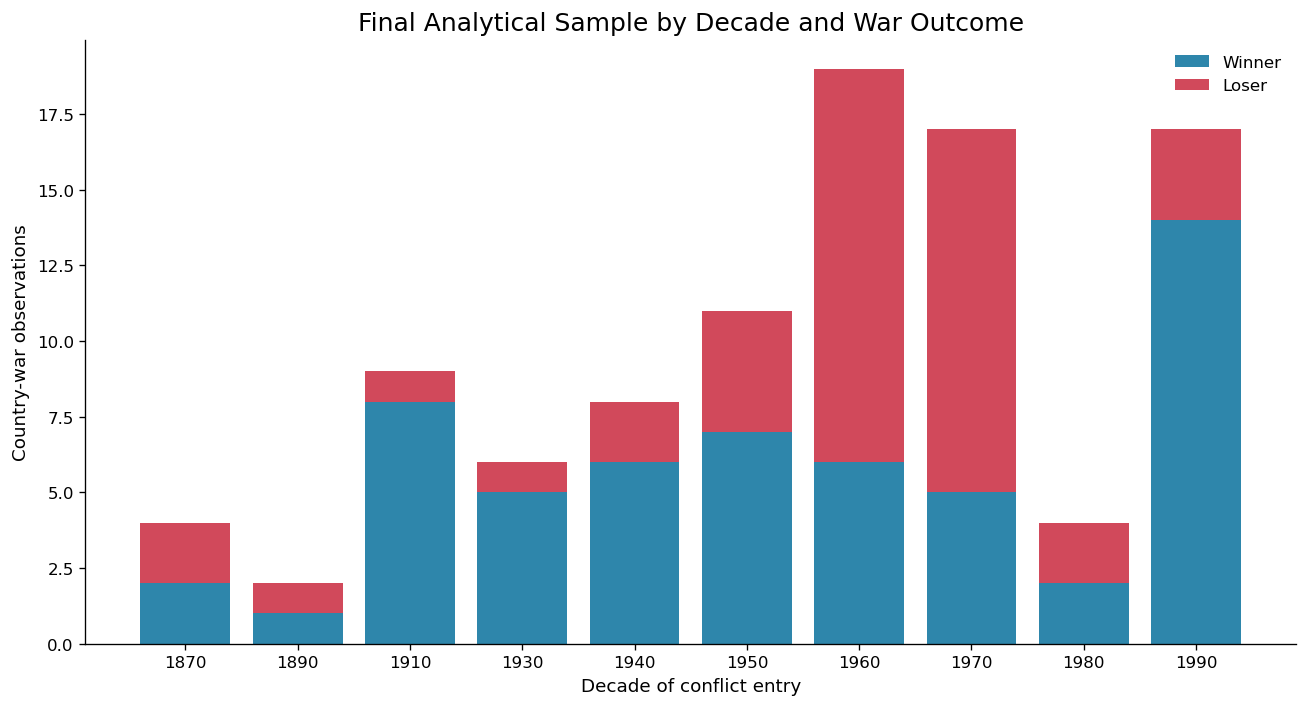

In [63]:
sample_plot = major_wars.copy()

sample_plot["decade"] = (
    sample_plot["entry_year"].astype(int) // 10
) * 10

decade_side = (
    sample_plot
    .groupby(["decade", "side"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Winner", "Loser"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    decade_side.index.astype(str),
    decade_side["Winner"],
    label="Winner",
    color=WINNER_COLOR
)

ax.bar(
    decade_side.index.astype(str),
    decade_side["Loser"],
    bottom=decade_side["Winner"],
    label="Loser",
    color=LOSER_COLOR
)

ax.set_title(
    "Final Analytical Sample by Decade and War Outcome"
)
ax.set_xlabel("Decade of conflict entry")
ax.set_ylabel("Country-war observations")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/fig01_sample_by_decade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The sample spans the late nineteenth to late twentieth century and is not evenly distributed across decades. It also contains more winner (56) than loser (41) observations, so aggregate comparisons should be read with that imbalance in mind.

#### Geographical Distribution of Wartime Economic Disruption

As mentioned in Topic 7, geospatial data combines location with attributes (*Introduction to geospatial data*, n.d.). The country boundaries are held in a GeoDataFrame and merged with the economic summary before plotting (*GeoPandas – an extension of Pandas*, n.d.). A choropleth then colours each mapped country by its median deepest wartime GDP change (*Choropleths*, n.d.).

`Former USSR` is deliberately left unmapped rather than being forced onto a modern national boundary.

In [64]:
import io
import zipfile
import shapefile
import geopandas as gpd
from shapely.geometry import shape
from matplotlib.colors import TwoSlopeNorm

# Natural Earth boundary data stored with the project.
boundary_zip = Path("data") / "ne_110m_admin_0_countries.zip"

if not boundary_zip.exists():
    raise FileNotFoundError(
        "Natural Earth boundary file not found. "
        "Place ne_110m_admin_0_countries.zip inside the data/ folder."
    )

# Read the shapefile directly from the ZIP using PyShp.
# This avoids GeoPandas' Fiona/Pyogrio file-reading dependencies.
with zipfile.ZipFile(boundary_zip) as z:
    shp_name = next(
        name for name in z.namelist()
        if name.lower().endswith(".shp")
    )

    base = shp_name[:-4]

    shp_bytes = io.BytesIO(z.read(base + ".shp"))
    shx_bytes = io.BytesIO(z.read(base + ".shx"))
    dbf_bytes = io.BytesIO(z.read(base + ".dbf"))

    reader = shapefile.Reader(
        shp=shp_bytes,
        shx=shx_bytes,
        dbf=dbf_bytes
    )

    field_names = [
        field[0] for field in reader.fields[1:]
    ]

    records = []
    geometries = []

    for item in reader.iterShapeRecords():
        records.append(
            dict(zip(field_names, item.record))
        )
        geometries.append(
            shape(item.shape.__geo_interface__)
        )

world = gpd.GeoDataFrame(
    records,
    geometry=geometries,
    crs="EPSG:4326"
)

# Natural Earth versions can use slightly different name columns.
if "ADMIN" in world.columns:
    world["map_name"] = world["ADMIN"]
elif "NAME" in world.columns:
    world["map_name"] = world["NAME"]
elif "name" in world.columns:
    world["map_name"] = world["name"]
else:
    raise KeyError(
        "No recognised country-name column was found."
    )

world = world[
    world["map_name"] != "Antarctica"
].copy()

print("Boundary countries loaded:", len(world))

Boundary countries loaded: 176


In [65]:
from pathlib import Path

matches = list(Path(".").rglob("ne_110m_admin_0_countries.zip"))

print("Found:", len(matches))

for p in matches:
    print(p.resolve())

Found: 1
C:\Users\User\OneDrive\Desktop\DV\data\ne_110m_admin_0_countries.zip


In [66]:
# Summarise wartime disruption at country level.
country_geo = (
    participant_metrics
    .groupby("mpd_country", as_index=False)
    .agg(
        median_wartime_disruption=(
            "deepest_wartime_change_pct",
            "median"
        ),
        war_observations=(
            "participant_id",
            "size"
        )
    )
)

world_names = set(world["map_name"].dropna())

# Resolve naming differences between Maddison and Natural Earth.
# Multiple candidates make the mapping robust to Natural Earth versions.
map_name_candidates = {
    "United States": [
        "United States of America",
        "United States"
    ],
    "Republic of Korea": [
        "South Korea",
        "Republic of Korea"
    ],
    "Syrian Arab Republic": [
        "Syria",
        "Syrian Arab Republic"
    ],
    "Lao People's DR": [
        "Laos",
        "Lao PDR",
        "Lao People's Democratic Republic"
    ],
    "Viet Nam": [
        "Vietnam",
        "Viet Nam"
    ],
    "U.R. of Tanzania: Mainland": [
        "Tanzania",
        "United Republic of Tanzania"
    ],
    "Taiwan, Province of China": [
        "Taiwan",
        "Taiwan Province of China"
    ],
    "Turkey": [
        "Turkey",
        "Türkiye"
    ]
}

def resolve_map_name(country):
    # The Former USSR series is intentionally not forced onto
    # a contemporary national boundary.
    if country == "Former USSR":
        return np.nan

    candidates = map_name_candidates.get(
        country,
        [country]
    )

    for candidate in candidates:
        if candidate in world_names:
            return candidate

    return np.nan

country_geo["map_name"] = (
    country_geo["mpd_country"]
    .apply(resolve_map_name)
)

unmapped_geo = country_geo.loc[
    country_geo["map_name"].isna(),
    ["mpd_country", "war_observations"]
]

print(
    "Countries represented on map:",
    country_geo["map_name"].notna().sum()
)

print("Countries not assigned to a map boundary:")
print(unmapped_geo.to_string(index=False))

Countries represented on map: 52
Countries not assigned to a map boundary:
mpd_country  war_observations
Former USSR                 1


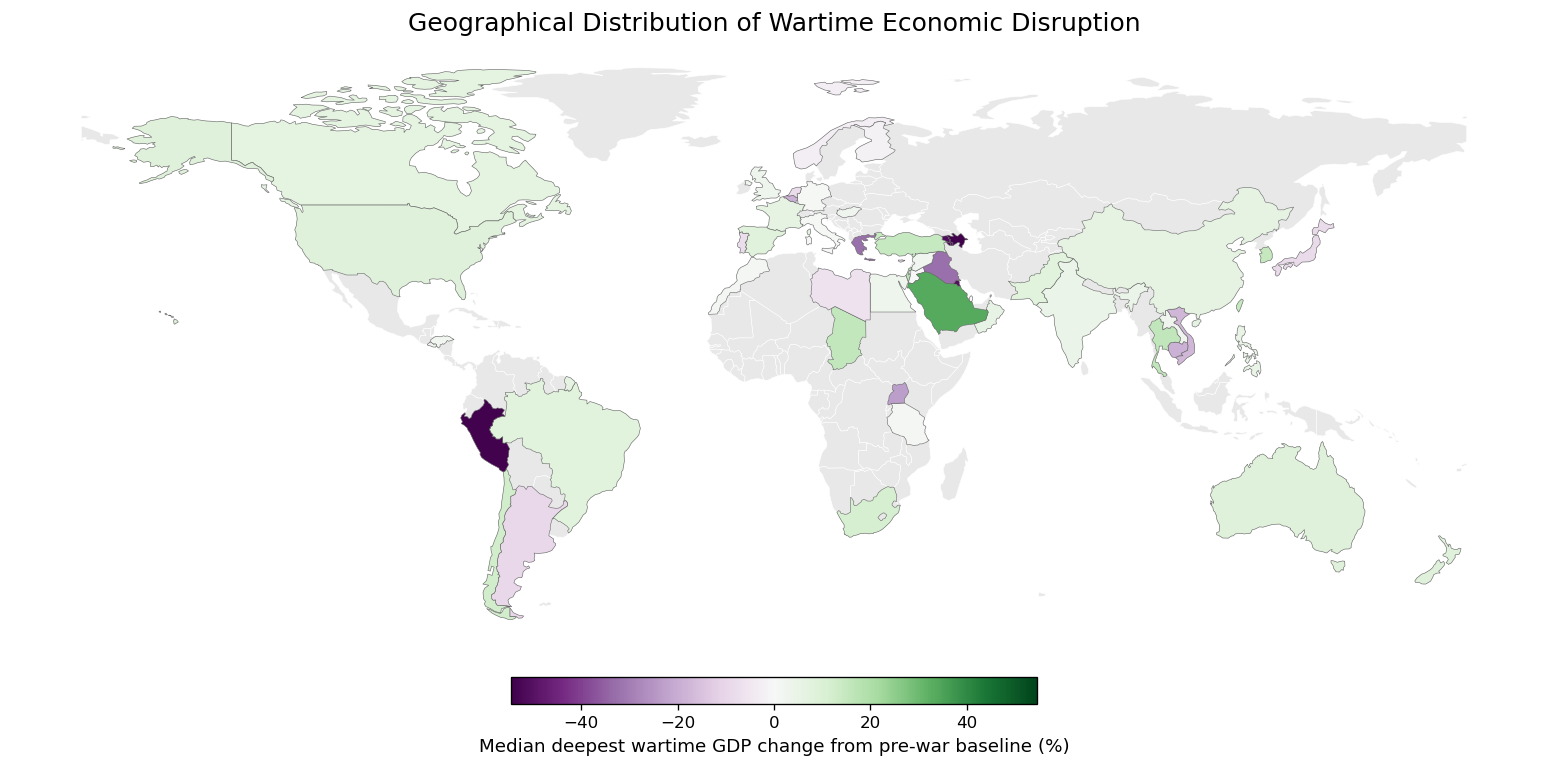

In [67]:
world_disruption = world.merge(
    country_geo[
        [
            "map_name",
            "median_wartime_disruption",
            "war_observations"
        ]
    ],
    on="map_name",
    how="left"
)

mapped_countries = world_disruption[
    world_disruption[
        "median_wartime_disruption"
    ].notna()
].copy()

# A diverging scale is centred on zero so that decreases
# and increases relative to the pre-war baseline are distinct.
max_abs_change = np.nanmax(
    np.abs(
        mapped_countries[
            "median_wartime_disruption"
        ]
    )
)

norm = TwoSlopeNorm(
    vmin=-max_abs_change,
    vcenter=0,
    vmax=max_abs_change
)

fig, ax = plt.subplots(figsize=(13, 7))

# Countries outside the analytical sample are shown in grey.
world_disruption.plot(
    ax=ax,
    color="#E8E8E8",
    edgecolor="white",
    linewidth=0.35
)

mapped_countries.plot(
    ax=ax,
    column="median_wartime_disruption",
    cmap="PRGn",
    norm=norm,
    edgecolor="#666666",
    linewidth=0.35
)

colour_scale = plt.cm.ScalarMappable(
    cmap="PRGn",
    norm=norm
)
colour_scale.set_array([])

cbar = fig.colorbar(
    colour_scale,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.04
)

cbar.set_label(
    "Median deepest wartime GDP change from pre-war baseline (%)"
)

ax.set_title(
    "Geographical Distribution of Wartime Economic Disruption"
)
ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    "figures/fig02_geographical_wartime_disruption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The map shows that wartime disruption varies widely across the countries in the sample rather than following one simple geographical pattern.

### RQ1: How Does GDP per Capita Change Before, During and After Interstate War?

#### Overall Event-Time Economic Trajectory

As mentioned in Topic 6, Lecture 1, line graphs are the most common way to communicate variables changing over time (Forth, n.d.-c). The median is used here to show the typical trajectory, with the interquartile range showing spread.

In [68]:
overall_trajectory = (
    trajectory_panel
    .groupby("analysis_time")["gdp_index"]
    .agg(
        median_index="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        observations="count"
    )
    .reset_index()
)

overall_trajectory.round(2)

,analysis_time,median_index,q1,q3,observations
0,-5,95.98,92.91,99.17,95
1,-4,97.35,95.05,100.03,97
2,-3,100.48,98.83,101.79,97
3,-2,102.53,100.52,103.88,97
4,-1,104.72,99.50,108.10,97
5,0,104.98,97.39,114.58,97
6,1,106.95,95.06,120.27,97
7,2,107.52,97.70,123.33,97
8,3,112.35,99.60,129.72,97
9,4,116.22,105.18,133.63,97


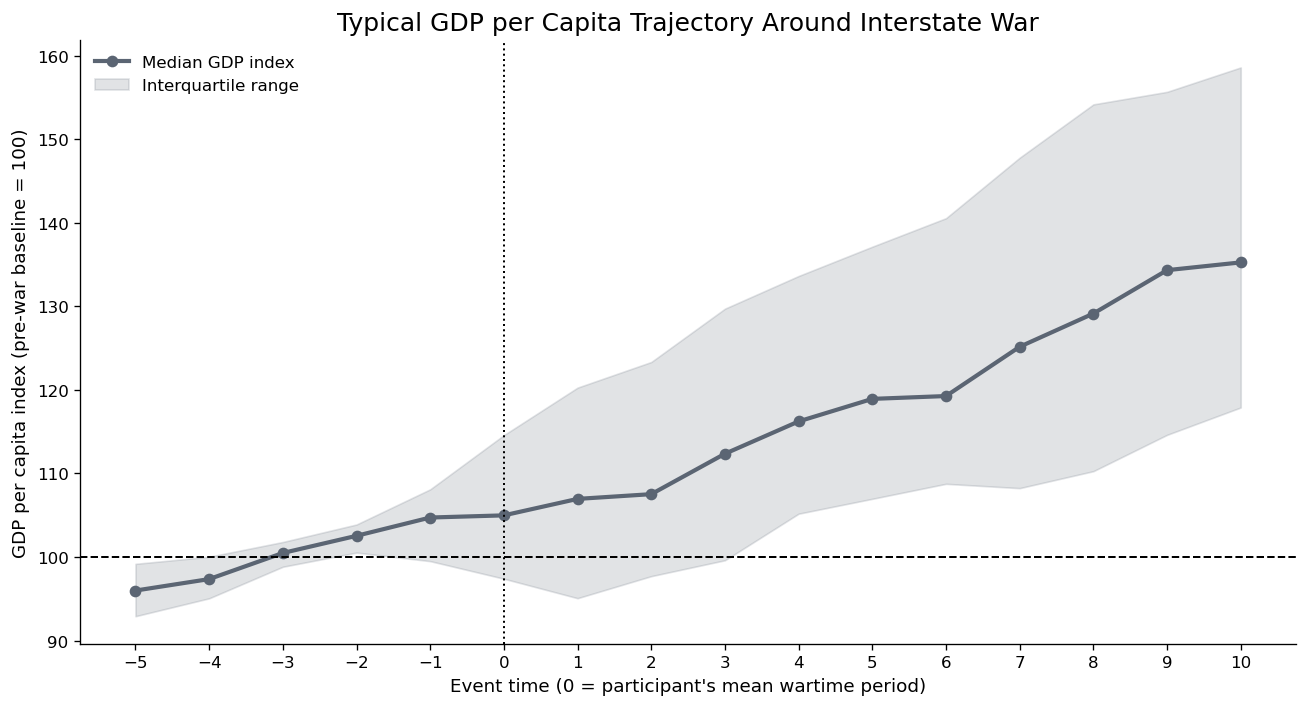

In [69]:
fig, ax = plt.subplots(figsize=(11, 6))

x = overall_trajectory["analysis_time"].to_numpy()

ax.plot(
    x,
    overall_trajectory["median_index"].to_numpy(),
    marker="o",
    linewidth=2.5,
    color=NEUTRAL_COLOR,
    label="Median GDP index"
)

ax.fill_between(
    x,
    overall_trajectory["q1"].to_numpy(),
    overall_trajectory["q3"].to_numpy(),
    alpha=0.18,
    color=NEUTRAL_COLOR,
    label="Interquartile range"
)

# Pre-war baseline
ax.axhline(
    100,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

# Wartime point
ax.axvline(
    0,
    linestyle=":",
    linewidth=1.2,
    color="black"
)

ax.set_xticks(range(-5, 11))

ax.set_title(
    "Typical GDP per Capita Trajectory Around Interstate War"
)

ax.set_xlabel(
    "Event time (0 = participant's mean wartime period)"
)

ax.set_ylabel(
    "GDP per capita index (pre-war baseline = 100)"
)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/fig03_overall_event_trajectory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### RQ1 Interpretation

The median participant does not show a universal wartime collapse: the index is about 105 during wartime and continues rising afterward. The wide interquartile range shows that individual country experiences differ substantially.

### RQ2: Do Winners and Losers Follow Different Economic Trajectories?

#### Winner–Loser Event-Time Comparison

Topic 6, Lecture 6 shows how comparing groups over time can reveal differences that are hard to see in raw tables (Forth, n.d.-b). Winner and loser median trajectories are therefore plotted on the same event-time axis.

In [70]:
side_trajectory = (
    trajectory_panel
    .groupby(
        ["side", "analysis_time"]
    )["gdp_index"]
    .agg(
        median_index="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        observations="count"
    )
    .reset_index()
)

side_trajectory.head()

,side,analysis_time,median_index,q1,q3,observations
0,Loser,-5,96.059571,92.550176,101.522547,40
1,Loser,-4,97.570689,95.297152,100.291323,41
2,Loser,-3,100.000000,98.619486,101.657852,41
3,Loser,-2,102.421502,100.600044,103.997152,41
4,Loser,-1,104.098861,97.789924,109.022082,41


In [71]:
trajectory_checkpoints = (
    side_trajectory[
        side_trajectory["analysis_time"].isin(
            [-5, -1, 0, 1, 5, 10]
        )
    ]
    .pivot(
        index="analysis_time",
        columns="side",
        values="median_index"
    )
    .round(2)
)

trajectory_checkpoints

side,Loser,Winner
analysis_time,,
-5,96.06,95.84
-1,104.10,105.23
0,104.09,106.20
1,103.35,108.87
5,116.42,119.84
10,137.11,132.76


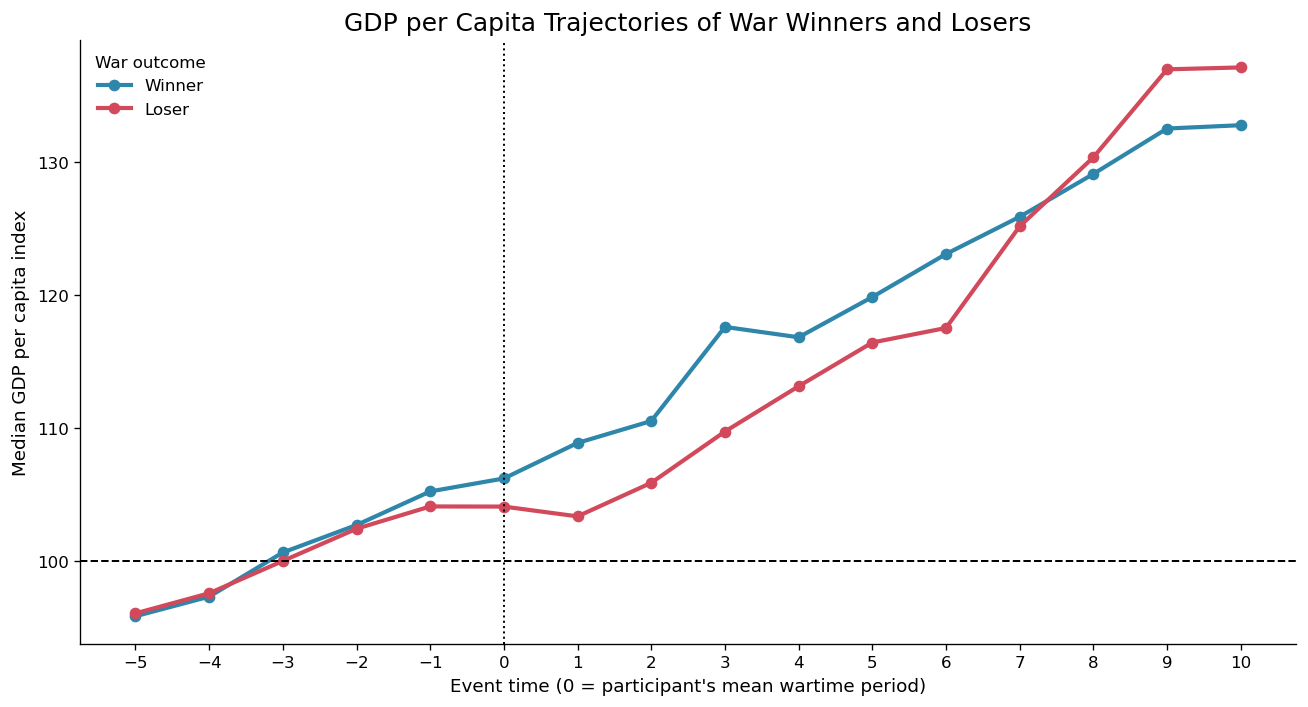

In [72]:
fig, ax = plt.subplots(figsize=(11, 6))

for side, color in [
    ("Winner", WINNER_COLOR),
    ("Loser", LOSER_COLOR)
]:
    group = side_trajectory[
        side_trajectory["side"] == side
    ]

    ax.plot(
        group["analysis_time"],
        group["median_index"],
        marker="o",
        linewidth=2.5,
        label=side,
        color=color
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.axvline(
    0,
    linestyle=":",
    linewidth=1.2,
    color="black"
)

ax.set_xticks(range(-5, 11))

ax.set_title(
    "GDP per Capita Trajectories of War Winners and Losers"
)

ax.set_xlabel(
    "Event time (0 = participant's mean wartime period)"
)

ax.set_ylabel(
    "Median GDP per capita index"
)

ax.legend(
    title="War outcome",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/fig04_winner_loser_trajectory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### RQ2 Interpretation

Winners and losers look similar before war, but winners are stronger immediately afterward: at +1 year the median index is about 109 for winners and 103 for losers. The gap later narrows and reverses, so victory is not linked to a consistently higher ten-year trajectory.

### RQ3: Does the Magnitude of Wartime Economic Disruption Differ Between Winners and Losers?

#### Deepest Wartime Economic Change

Wartime disruption is measured as each participant's lowest wartime GDP index relative to the pre-war baseline.

In [73]:
disruption_summary = (
    participant_metrics
    .groupby("side")
    .agg(
        participants=(
            "participant_id",
            "size"
        ),
        median_deepest_change=(
            "deepest_wartime_change_pct",
            "median"
        ),
        q1=(
            "deepest_wartime_change_pct",
            lambda x: x.quantile(0.25)
        ),
        q3=(
            "deepest_wartime_change_pct",
            lambda x: x.quantile(0.75)
        ),
        below_baseline=(
            "deepest_wartime_change_pct",
            lambda x: (x < 0).sum()
        )
    )
    .reset_index()
)

disruption_summary["below_baseline_pct"] = (
    disruption_summary["below_baseline"] /
    disruption_summary["participants"] *
    100
)

disruption_summary.round(2)

,side,participants,median_deepest_change,q1,q3,below_baseline,below_baseline_pct
0,Loser,41,2.09,-7.33,6.79,17,41.46
1,Winner,56,4.82,-2.05,10.62,16,28.57


C:\Users\User\AppData\Local\Temp\ipykernel_26208\81876398.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


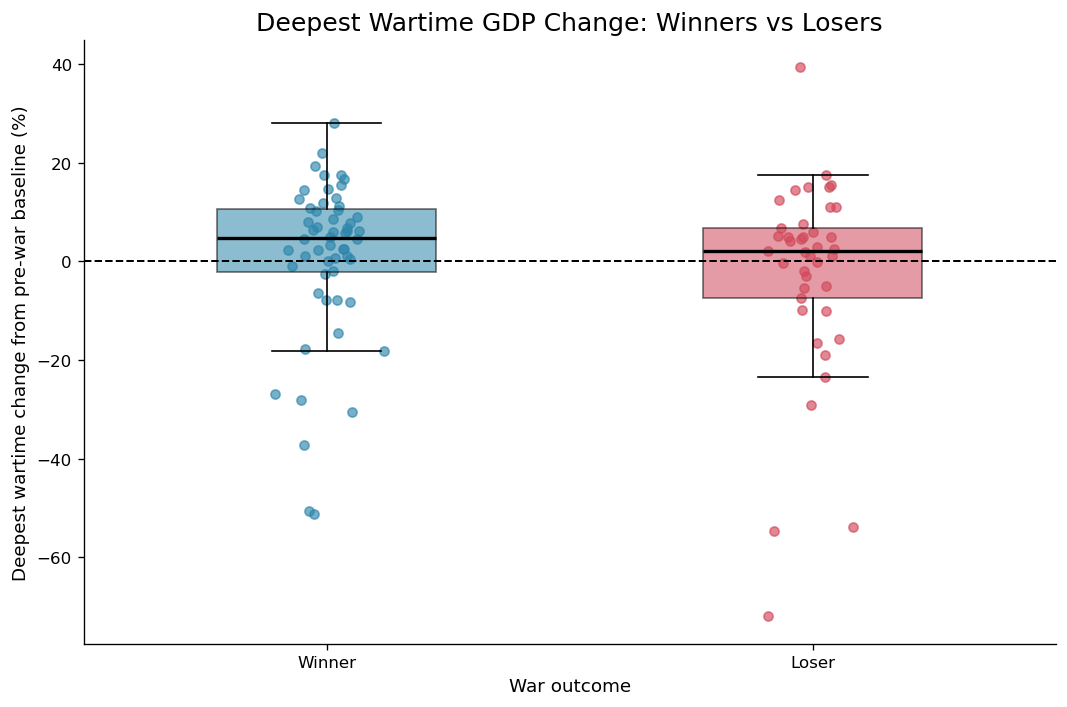

In [74]:
winner_values = (
    participant_metrics.loc[
        participant_metrics["side"] == "Winner",
        "deepest_wartime_change_pct"
    ]
    .dropna()
    .to_numpy()
)

loser_values = (
    participant_metrics.loc[
        participant_metrics["side"] == "Loser",
        "deepest_wartime_change_pct"
    ]
    .dropna()
    .to_numpy()
)

fig, ax = plt.subplots(figsize=(9, 6))

box = ax.boxplot(
    [winner_values, loser_values],
    labels=["Winner", "Loser"],
    patch_artist=True,
    showfliers=False,
    widths=0.45,
    medianprops={
        "color": "black",
        "linewidth": 2
    }
)

box["boxes"][0].set_facecolor(WINNER_COLOR)
box["boxes"][1].set_facecolor(LOSER_COLOR)

box["boxes"][0].set_alpha(0.55)
box["boxes"][1].set_alpha(0.55)

# Add individual observations with reproducible jitter
rng = np.random.default_rng(42)

for position, values, color in [
    (1, winner_values, WINNER_COLOR),
    (2, loser_values, LOSER_COLOR)
]:
    jitter = rng.normal(
        position,
        0.055,
        size=len(values)
    )

    ax.scatter(
        jitter,
        values,
        alpha=0.65,
        s=30,
        color=color
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.set_title(
    "Deepest Wartime GDP Change: Winners vs Losers"
)

ax.set_xlabel("War outcome")

ax.set_ylabel(
    "Deepest wartime change from pre-war baseline (%)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/fig05_wartime_disruption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### RQ3 Interpretation

About 41% of loser observations fell below their pre-war baseline during wartime, compared with about 29% of winners. The distributions still overlap strongly, so outcome alone does not explain wartime economic performance.

### RQ4: How Quickly Do Winning and Losing Countries Recover?

#### Time to Recovery

Recovery is the first post-war year in which GDP returns to at least 100. Only participants ending wartime below baseline are included in this calculation.

In [75]:
# Keep only participants that ended the wartime period
# below their pre-war GDP baseline

recovery_sample = participant_metrics[
    participant_metrics["recovery_needed"]
].copy()

print(
    "Participants requiring recovery:",
    len(recovery_sample)
)

print("\nBy war outcome:")
print(
    recovery_sample["side"]
    .value_counts()
)

Participants requiring recovery: 30

By war outcome:
side
Loser     16
Winner    14
Name: count, dtype: int64


In [76]:
recovery_summary = (
    recovery_sample
    .groupby("side")
    .agg(
        participants_requiring_recovery=(
            "participant_id",
            "size"
        ),
        recovered_within_10_years=(
            "recovery_year",
            lambda x: x.notna().sum()
        ),
        median_recovery_year_among_recovered=(
            "recovery_year",
            "median"
        )
    )
    .reset_index()
)

recovery_summary[
    "recovered_within_10_years_pct"
] = (
    recovery_summary[
        "recovered_within_10_years"
    ] /
    recovery_summary[
        "participants_requiring_recovery"
    ] * 100
)

recovery_summary.round(2)

,side,participants_requiring_recovery,recovered_within_10_years,median_recovery_year_among_recovered,recovered_within_10_years_pct
0,Loser,16,11,2.0,68.75
1,Winner,14,11,4.0,78.57


#### Cumulative Post-War Recovery

In [77]:
recovery_curve_rows = []

for side, group in recovery_sample.groupby("side"):

    total = len(group)

    for year in range(1, 11):

        recovered = (
            group["recovery_year"].notna() &
            (group["recovery_year"] <= year)
        ).sum()

        recovery_curve_rows.append({
            "side": side,
            "postwar_year": year,
            "recovered": recovered,
            "total": total,
            "cumulative_recovery_pct":
                recovered / total * 100
        })

recovery_curve = pd.DataFrame(
    recovery_curve_rows
)

recovery_curve.pivot(
    index="postwar_year",
    columns="side",
    values="cumulative_recovery_pct"
).round(1)

side,Loser,Winner
postwar_year,,
1,6.2,7.1
2,37.5,14.3
3,43.8,28.6
4,43.8,50.0
5,43.8,50.0
6,43.8,57.1
7,56.2,57.1
8,56.2,71.4
9,62.5,78.6


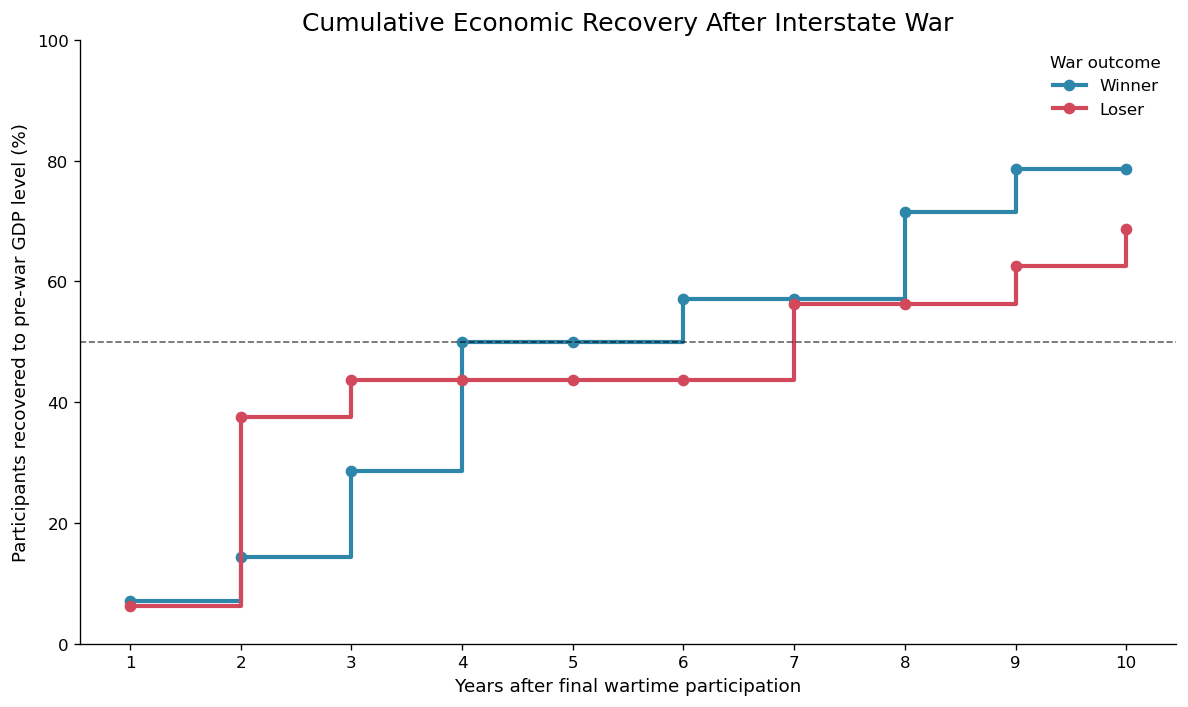

In [78]:
fig, ax = plt.subplots(figsize=(10, 6))

for side, color in [
    ('Winner', WINNER_COLOR),
    ('Loser', LOSER_COLOR)
]:
    group = recovery_curve[recovery_curve['side'] == side]

    ax.plot(
        group['postwar_year'],
        group['cumulative_recovery_pct'],
        marker='o',
        linewidth=2.5,
        drawstyle='steps-post',
        label=side,
        color=color
    )

ax.axhline(50, linestyle='--', linewidth=1, color='black', alpha=0.6)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 100)
ax.set_title('Cumulative Economic Recovery After Interstate War')
ax.set_xlabel('Years after final wartime participation')
ax.set_ylabel('Participants recovered to pre-war GDP level (%)')
ax.legend(title='War outcome', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    'figures/fig06_cumulative_recovery.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### RQ4 Interpretation

Losers recover earlier in the first few years, but by year 10 about 79% of winners needing recovery have returned to baseline compared with about 69% of losers. Recovery therefore differs in timing as well as final proportion.

### RQ5: How Do Wartime and Post-War Economic Indicators Vary Jointly Across Winners and Losers?

#### Multidimensional Economic Profiles

As mentioned in Topic 9, Lecture 3, multidimensional data often needs preprocessing before it can be visualised clearly (*Visualising multidimensional data*, n.d.). A parallel-coordinates plot is used here to compare four economic indicators at once. All four are percentage changes from the same pre-war baseline, then min–max scaled within each feature for the plot.

In [79]:
profile_features = {
    'deepest_wartime_change_pct': 'Deepest wartime change',
    'wartime_mean_change_pct': 'Mean wartime change',
    'postwar_1_5_change_pct': 'Post-war years 1–5',
    'postwar_6_10_change_pct': 'Post-war years 6–10'
}

profile_data = participant_metrics[
    ['participant_id', 'side'] + list(profile_features.keys())
].dropna().copy()

# Actual median values remain in percentage-change units.
profile_medians = (
    profile_data
    .groupby('side')[list(profile_features.keys())]
    .median()
    .rename(columns=profile_features)
    .round(2)
)

profile_medians

,Deepest wartime change,Mean wartime change,Post-war years 1–5,Post-war years 6–10
side,,,,
Loser,2.09,4.09,8.13,28.87
Winner,4.82,6.20,14.78,27.96


In [80]:
# Min–max scale each dimension only for the parallel-coordinates display.
profile_plot = profile_data[['participant_id', 'side']].copy()
plot_columns = []

for feature, label in profile_features.items():
    minimum = profile_data[feature].min()
    maximum = profile_data[feature].max()

    profile_plot[label] = (
        (profile_data[feature] - minimum) /
        (maximum - minimum)
    )
    plot_columns.append(label)

profile_plot.head()

,participant_id,side,Deepest wartime change,Mean wartime change,Post-war years 1–5,Post-war years 6–10
0,58_220,Loser,0.620294,0.410050,0.267841,0.158998
1,58_255,Winner,0.652006,0.440612,0.290079,0.171310
2,64_155,Winner,0.759673,0.662328,0.373596,0.278304
3,64_135,Loser,0.161715,0.029536,0.055124,0.000000
4,79_230,Loser,0.683121,0.465279,0.269477,0.161295


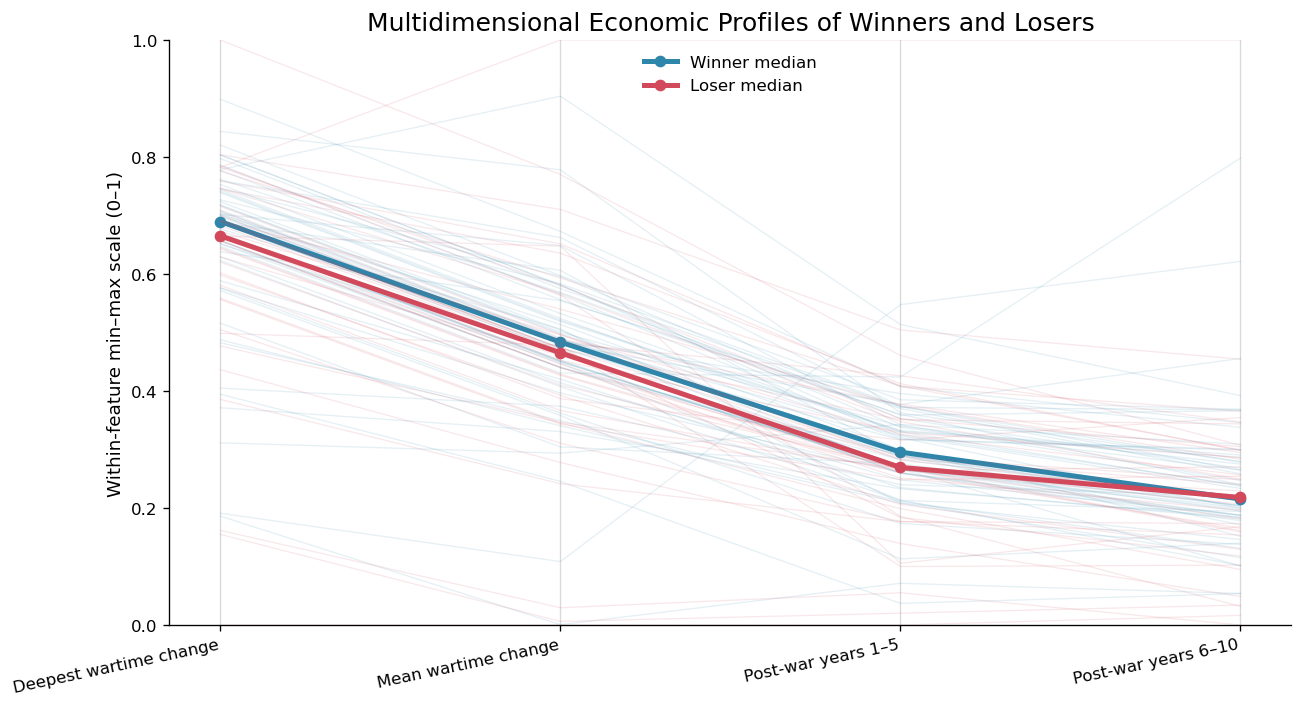

In [81]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(plot_columns))

# Light individual profiles show spread; thick lines show group medians.
for side, color in [
    ('Winner', WINNER_COLOR),
    ('Loser', LOSER_COLOR)
]:
    group = profile_plot[profile_plot['side'] == side]

    for _, row in group.iterrows():
        ax.plot(
            x,
            row[plot_columns].to_numpy(dtype=float),
            color=color,
            alpha=0.12,
            linewidth=0.8
        )

    median_profile = group[plot_columns].median()
    ax.plot(
        x,
        median_profile.to_numpy(dtype=float),
        color=color,
        linewidth=3,
        marker='o',
        label=f'{side} median'
    )

for xpos in x:
    ax.axvline(xpos, color='#D9D9D9', linewidth=0.8, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(plot_columns, rotation=12, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Within-feature min–max scale (0–1)')
ax.set_title('Multidimensional Economic Profiles of Winners and Losers')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    'figures/fig07_parallel_coordinates_profiles.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### RQ5 Interpretation

The median winner profile is stronger during wartime and in post-war years 1–5, while the later post-war medians are very similar. The many overlapping individual lines also show substantial variation inside both groups. The multidimensional view therefore supports the earlier result: winner/loser status is related to some short-term differences but does not define one fixed economic path.

### Sensitivity Analysis: Excluding Subsequent War Overlaps

The main sample keeps repeat-war participants. As a robustness check, the key trajectory and recovery results are repeated after removing observations whose ten-year post-war window overlaps another COW interstate war.

In [82]:
# Participants with no subsequent interstate-war overlap
sensitivity_ids = major_wars.loc[
    ~major_wars["postwar_conflict_overlap"],
    "participant_id"
]

trajectory_sensitivity = trajectory_panel[
    trajectory_panel["participant_id"].isin(
        sensitivity_ids
    )
].copy()

metrics_sensitivity = participant_metrics[
    participant_metrics["participant_id"].isin(
        sensitivity_ids
    )
].copy()

print(
    "Primary sample participants:",
    major_wars["participant_id"].nunique()
)

print(
    "Sensitivity sample participants:",
    metrics_sensitivity["participant_id"].nunique()
)

print("\nSensitivity sample by outcome:")
print(
    metrics_sensitivity["side"].value_counts()
)

Primary sample participants: 97
Sensitivity sample participants: 63

Sensitivity sample by outcome:
side
Winner    34
Loser     29
Name: count, dtype: int64


#### Winner–Loser Trajectories Without Subsequent War Overlap

In [83]:
sensitivity_side_trajectory = (
    trajectory_sensitivity
    .groupby(
        ["side", "analysis_time"]
    )["gdp_index"]
    .median()
    .reset_index(name="median_index")
)

sensitivity_side_trajectory.head()

,side,analysis_time,median_index
0,Loser,-5,96.141444
1,Loser,-4,97.570689
2,Loser,-3,100.000000
3,Loser,-2,102.189097
4,Loser,-1,103.851400


In [84]:
sensitivity_checkpoints = (
    sensitivity_side_trajectory[
        sensitivity_side_trajectory[
            "analysis_time"
        ].isin(
            [-5, -1, 0, 1, 5, 10]
        )
    ]
    .pivot(
        index="analysis_time",
        columns="side",
        values="median_index"
    )
    .round(2)
)

sensitivity_checkpoints

side,Loser,Winner
analysis_time,,
-5,96.14,97.77
-1,103.85,104.24
0,104.09,105.39
1,104.40,108.47
5,122.31,120.74
10,141.41,132.76


In [85]:
primary_checkpoints = (
    side_trajectory[
        side_trajectory[
            "analysis_time"
        ].isin(
            [0, 1, 5, 10]
        )
    ]
    .pivot(
        index="analysis_time",
        columns="side",
        values="median_index"
    )
)

sensitivity_comparison = pd.DataFrame({
    "Primary Winner": (
        primary_checkpoints["Winner"]
    ),
    "No-overlap Winner": (
        sensitivity_checkpoints["Winner"]
    ),
    "Primary Loser": (
        primary_checkpoints["Loser"]
    ),
    "No-overlap Loser": (
        sensitivity_checkpoints["Loser"]
    )
}).round(2)

sensitivity_comparison

,Primary Winner,No-overlap Winner,Primary Loser,No-overlap Loser
analysis_time,,,,
-5,NaN,97.77,NaN,96.14
-1,NaN,104.24,NaN,103.85
0,106.20,105.39,104.09,104.09
1,108.87,108.47,103.35,104.40
5,119.84,120.74,116.42,122.31
10,132.76,132.76,137.11,141.41


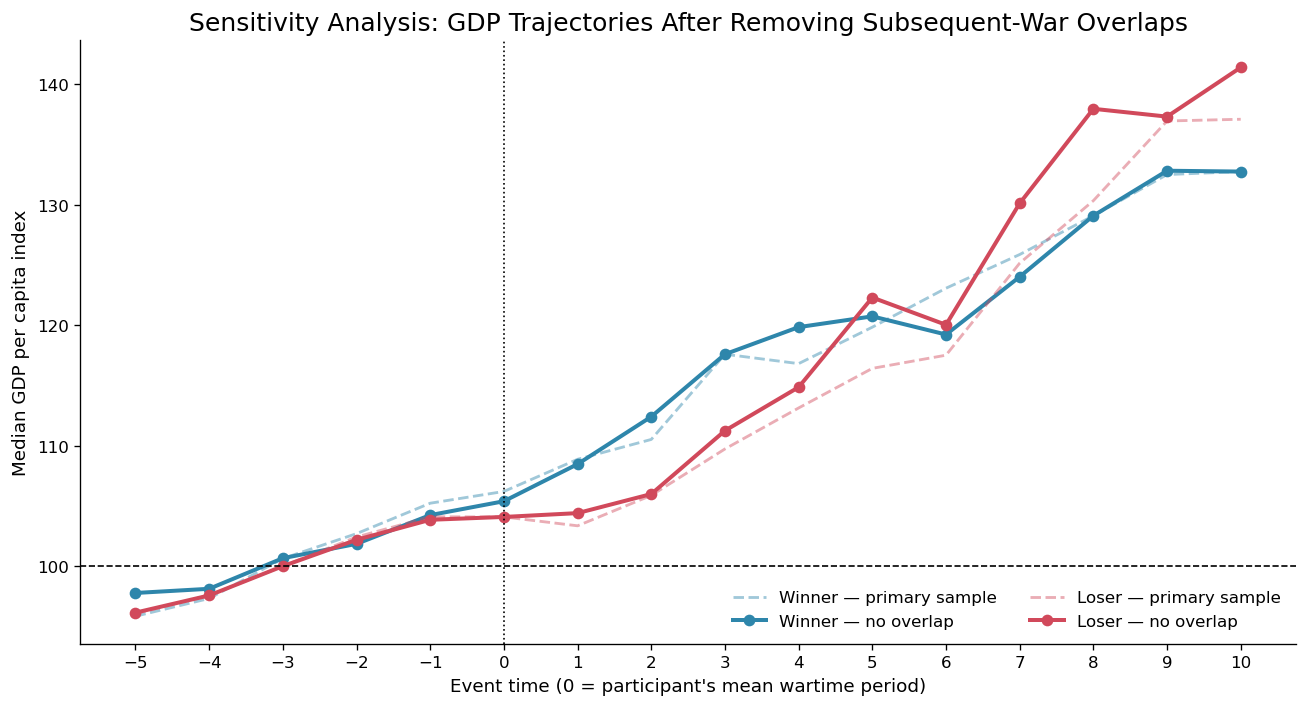

In [86]:
fig, ax = plt.subplots(figsize=(11, 6))

# Primary trajectories shown as lighter dashed lines
for side, color in [
    ("Winner", WINNER_COLOR),
    ("Loser", LOSER_COLOR)
]:
    primary_group = side_trajectory[
        side_trajectory["side"] == side
    ]

    sensitivity_group = (
        sensitivity_side_trajectory[
            sensitivity_side_trajectory[
                "side"
            ] == side
        ]
    )

    ax.plot(
        primary_group["analysis_time"],
        primary_group["median_index"],
        linestyle="--",
        linewidth=1.7,
        alpha=0.45,
        color=color,
        label=f"{side} — primary sample"
    )

    ax.plot(
        sensitivity_group["analysis_time"],
        sensitivity_group["median_index"],
        marker="o",
        linewidth=2.4,
        color=color,
        label=f"{side} — no overlap"
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1,
    color="black"
)

ax.axvline(
    0,
    linestyle=":",
    linewidth=1,
    color="black"
)

ax.set_xticks(range(-5, 11))

ax.set_title(
    "Sensitivity Analysis: GDP Trajectories After Removing Subsequent-War Overlaps"
)

ax.set_xlabel(
    "Event time (0 = participant's mean wartime period)"
)

ax.set_ylabel(
    "Median GDP per capita index"
)

ax.legend(
    frameon=False,
    ncol=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/fig08_sensitivity_trajectory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The broad trajectory remains similar after removing the 34 overlap cases: winners are stronger immediately after war, while the later difference narrows and reverses. The main pattern is therefore not driven only by repeat-war participants.

#### Recovery Sensitivity Check

In [87]:
recovery_sensitivity = metrics_sensitivity[
    metrics_sensitivity["recovery_needed"]
].copy()

print(
    "Participants requiring recovery:",
    len(recovery_sensitivity)
)

print("\nBy outcome:")
print(
    recovery_sensitivity["side"]
    .value_counts()
)

Participants requiring recovery: 20

By outcome:
side
Loser     11
Winner     9
Name: count, dtype: int64


In [88]:
recovery_sensitivity_summary = (
    recovery_sensitivity
    .groupby("side")
    .agg(
        requiring_recovery=(
            "participant_id",
            "size"
        ),
        recovered_within_10_years=(
            "recovery_year",
            lambda x: x.notna().sum()
        )
    )
    .reset_index()
)

recovery_sensitivity_summary[
    "recovered_pct"
] = (
    recovery_sensitivity_summary[
        "recovered_within_10_years"
    ] /
    recovery_sensitivity_summary[
        "requiring_recovery"
    ] * 100
)

recovery_sensitivity_summary.round(2)

,side,requiring_recovery,recovered_within_10_years,recovered_pct
0,Loser,11,6,54.55
1,Winner,9,8,88.89


In [89]:
sensitivity_recovery_rows = []

for side, group in recovery_sensitivity.groupby(
    "side"
):

    total = len(group)

    for year in range(1, 11):

        recovered = (
            group["recovery_year"].notna() &
            (group["recovery_year"] <= year)
        ).sum()

        sensitivity_recovery_rows.append({
            "side": side,
            "postwar_year": year,
            "cumulative_recovery_pct":
                recovered / total * 100
        })

sensitivity_recovery_curve = pd.DataFrame(
    sensitivity_recovery_rows
)

sensitivity_recovery_curve.pivot(
    index="postwar_year",
    columns="side",
    values="cumulative_recovery_pct"
).round(1)

side,Loser,Winner
postwar_year,,
1,9.1,11.1
2,18.2,22.2
3,27.3,33.3
4,27.3,55.6
5,27.3,55.6
6,27.3,66.7
7,36.4,66.7
8,36.4,88.9
9,45.5,88.9


In the restricted recovery sample, about 89% of winners recover within ten years compared with about 55% of losers. Only 20 participants require recovery here, so this sensitivity result should be treated cautiously.

### Analysis Summary

The analysis shows substantial variation around interstate war. Winners are generally stronger immediately after conflict and losers more often experience below-baseline wartime GDP, but the groups overlap heavily and the later post-war gap is not stable. The parallel-coordinates view reaches the same conclusion across several indicators at once.

As noted in Topic 6, time-series relationships are descriptive and do not by themselves establish causation (Forth, n.d.-c).

## Critical Engagement with AI

AI was used for brainstorming, debugging and checking possible visualisation approaches, but its outputs were verified rather than treated as evidence. An early AI-generated `major_wars.csv` had no clear provenance and contained problems such as global war dates being applied to countries that entered later. I therefore rejected it and rebuilt the conflict table from raw COW data using reproducible Python rules. This was a useful reminder that AI can speed up exploration, but historical facts, mappings and methodological choices still need independent checking.

## Conclusions

### Key Findings

The final sample covers 97 country-war observations from 25 interstate wars. Winners tend to show stronger GDP performance immediately after conflict, while losers are more likely to fall below baseline during wartime. However, later trajectories overlap and sometimes reverse, and the multidimensional profile shows substantial variation within both groups.

The evidence therefore supports an **association** between war outcome and parts of the economic trajectory, not a simple rule that winning produces better long-run economic performance.

### Limitations and Assumptions

This is an observational study, so it cannot show that victory or defeat causes GDP changes. Historical GDP coverage is uneven, political boundaries change over time, and the five-year baseline and ten-year recovery window are analytical choices. GDP per capita also measures output rather than welfare, casualties or displacement. Finally, repeated wars can affect recovery, although the sensitivity analysis suggests the main visual pattern is not solely driven by those cases.

### Future Research

Future work could add conflict intensity, battle location, trade disruption or government spending, and could extend the economic series beyond 2018. Statistical models accounting for repeated countries and wars would also help separate outcome effects from other differences between participants.

## Critical Engagement with AI

AI was used mainly for support and checking. Claude first suggested using a simplified `major_wars.csv`, but after reviewing it there were problems with participant dates, duplicated casualty figures and some outcome classifications. ChatGPT suggested replacing it with the **COW Inter-State War Data v4.0**, which was then combined with **MPD2020** for GDP per capita and Natural Earth for the map.

ChatGPT also helped with debugging and small notebook issues, such as creating a Python version of the word-count script when the original JavaScript version did not work in the Jupyter environment. All AI suggestions were still tested and checked before being used.

## References

Bolt, J. and van Zanden, J.L. (2020). *Maddison style estimates of the evolution of the world economy: A new 2020 update*. Maddison Project Database, version 2020.

*Choropleths* (n.d.). Topic 7: Geospatial Data. *Data Visualisation* [lecture]. University of London.

Forth, J. (n.d.-a). *Aggregation and merging*. Topic 6: Time-series Data. *Data Visualisation* [lecture]. Goldsmiths, University of London.

Forth, J. (n.d.-b). *Time-series analysis*. Topic 6: Time-series Data. *Data Visualisation* [lecture]. Goldsmiths, University of London.

Forth, J. (n.d.-c). *Time-series data*. Topic 6: Time-series Data. *Data Visualisation* [lecture]. Goldsmiths, University of London.

*GeoPandas – an extension of Pandas* (n.d.). Topic 7: Geospatial Data. *Data Visualisation* [lecture]. University of London.

*Introduction to geospatial data* (n.d.). Topic 7: Geospatial Data. *Data Visualisation* [lecture]. University of London.

Maddison Project Database (2020). *Maddison Project Database, version 2020*. Groningen Growth and Development Centre, University of Groningen.

Natural Earth (n.d.). *1:110m Cultural Vectors: Admin 0 – Countries*. Available at: https://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-admin-0-countries/

Sarkees, M.R. (2010). *Inter-State Wars (Version 4.0): Definitions and Variables*. Correlates of War Project.

Sarkees, M.R. and Wayman, F.W. (2010). *Resort to War: 1816–2007*. Washington, DC: CQ Press.

*Visualising multidimensional data* (n.d.). Topic 9: Large and High-Dimensional Data. *Data Visualisation* [lecture]. University of London.

Zimmer, R. (n.d.). *Nominal Variables*. *Data Visualisation* [lecture]. University of London.

## Appendices

### Appendix A: Country-Name Harmonisation

### Appendix B: Excluded Historical-State Mappings

### Appendix C: Final 25-War Analytical Sample

### Appendix D: GDP Coverage Criteria and Exclusions

### Appendix E: Additional Sensitivity Results

## Word Count

The following code counts words in Markdown cells. `Main word count` excludes References and Appendices. Do not modify the code cell below.

In [90]:
import json
import re
from pathlib import Path

NOTEBOOK_FILE = Path("DSM050_FINAL_AbdallaSoliman_AS2171.ipynb")

with open(NOTEBOOK_FILE, "r", encoding="utf-8") as f:
    notebook = json.load(f)

word_count = 0
extra_count = 0
main_body = True

for cell in notebook["cells"]:
    if cell["cell_type"] != "markdown":
        continue

    text = "".join(cell["source"])

    # Stop counting as main body at References or Appendices.
    if (
        text.startswith("## References")
        or text.startswith("## Appendices")
    ):
        main_body = False

    # Do not count the Word Count section.
    if text.startswith("## Word Count"):
        text = ""

    if text:
        words = re.findall(r"\b[a-z\d]+\b", text.lower())
        cell_count = len(words)

        if main_body:
            word_count += cell_count
        else:
            extra_count += cell_count

print(
    f"Main word count: {word_count} "
    f"(References and appendices word count: {extra_count})"
)

Main word count: 1824 (References and appendices word count: 271)
